# NB3 — Tile-Set Attention → IV Prediction (V5 — 7 heads + physics constraints)

**Env:** `torchfifty`  
**Input:** `lucia_tile_features.parquet` — 162 tiles × 22 features per cell (~205 MB)  
**Architecture:** PerTileMLP(Dropout 0.3) → gated MIL attention pool → **7 IV heads** (μ±σ, heteroscedastic NLL)  
**Contrastive aux:** InfoNCE image↔tabular (CONTRASTIVE_W=0.1) — regulariser, not predictor  
**Heads (V5):** `Voc, Isc, Vmax, Imax, FF, Pmax, Rs` — all 7 directly predicted  
**Physics constraints (soft, multiplication form):**  
`C1: Pmax = Vmax·Imax`,  `C2: Pmax = FF·Voc·Isc`,  `C3: Vmax·Imax = FF·Voc·Isc`  
Normalised by μ_Pmax; applied after MSE warm-up; λ_c=0.1  
**Derived (audit only — never heads):**  
`Imax_derived = Pmax/Vmax`,  `Isc_derived = Pmax/(FF·Voc)` — reported as consistency check

**Why V5 / 7 heads:** V4 derived Isc via Pmax/(FF·Voc) → chained 3 noisy quantities in a ratio → r²=−7.56.  
Direct supervision + constraint gives Isc/Imax their own gradient path. Current ceiling (~0.65–0.75 R²) is the  
optical/modality limit, not propagation error. Constraint ensures physical self-consistency.

| Section | Content |
|---|---|
| §4.1 | Data loading, PT normalization, PT params for constraint, cell features |
| §4.2 | TileSetDataset (returns tile features + tabular features) |
| §4.3 | PerTileMLP + AttnMILPool + IVHeads (7) + physics_constraint_loss |
| §4.4 | Training: MSE warm-up → β-NLL + constraint losses |
| §4.5 | Evaluation: R²/ρ on 7 heads; derived audit; constraint residuals |
| §4.6 | Attention maps → 9×18 defect grid, saved for NB4 overlay |
| §4.7 | Comparison table vs RF / HistGB / MLP baselines; acceptance gate |
| §4.8 | UBELIX — Tier-B CNN backbone; CUDA batch size; run order |

**Acceptance gate:** FF R²≥0.85 AND Pmax R²≥0.87 (direct heads — fair vs baselines)  
**Tier B (UBELIX):** PerTileMLP replaced by a shared tiny CNN reading 64×64 tile pixels.

In [1]:
# ── Env check + imports ───────────────────────────────────────────────────────
import os, sys, json, pickle, glob, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import r2_score

N_CORES = os.cpu_count() or 4
torch.set_num_threads(N_CORES)
torch.set_num_interop_threads(max(1, N_CORES // 2))

# LUCIA_ROOT: env var → auto-detect UBELIX → local fallback
_LUCIA_ROOT = os.environ.get('LUCIA_ROOT',
    '/storage/homefs/db98d082/ondemand/LUCIA'
    if os.path.isdir('/storage/homefs/db98d082') else
    '/home/derk/DataScience/CAS_projects/LUCIA')
sys.path.insert(0, str(Path(_LUCIA_ROOT) / 'notebooks_scripts'))
import lucia_common as lc

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_ID     = datetime.now().strftime("%Y%m%d_%H%M%S")
SEED       = 42
torch.manual_seed(SEED); np.random.seed(SEED)

N_TILES    = 162
TILE_ROWS  = 9
TILE_COLS  = 18

# V5 strategy: 7 direct heads + soft physics constraints.
# All IV parameters predicted directly — Isc and Imax get their own gradient paths.
# Constraints enforce Pmax = Vmax·Imax = FF·Voc·Isc (soft, multiplication form, no divisions).
# Derived quantities reported as audit only — physics consistency check, not model outputs.
IV_TARGETS    = ['Voc', 'Isc', 'Vmax', 'Imax', 'FF', 'Pmax', 'Rs']
N_TARGETS     = len(IV_TARGETS)   # 7
DERIVED_AUDIT = ['Imax_derived', 'Isc_derived']  # Pmax/Vmax and Pmax/(FF·Voc)

CONTRASTIVE_W    = 0.05   # InfoNCE weight; set 0.0 to disable  [Optuna best]
LAMBDA_C         = 0.1   # physics constraint weight  [Optuna best]
FEAT_NOISE_SIGMA = 0.0  # Gaussian noise σ on tile features (train augmentation)
TILE_DROPOUT_P   = 0.0  # fraction of tiles zeroed per sample (train augmentation)


for d in [lc.FIGURES, f"{lc.DOCS}/03_Models", f"{lc.DOCS}/04_Results", lc.MODELS]:
    os.makedirs(d, exist_ok=True)

print(f"torch {torch.__version__}  device: {DEVICE}  cores: {N_CORES}")
print(f"RUN_ID: {RUN_ID}")
print(f"IV_TARGETS ({N_TARGETS}): {IV_TARGETS}")
print(f"CONTRASTIVE_W: {CONTRASTIVE_W}  LAMBDA_C: {LAMBDA_C}  noise_σ: {FEAT_NOISE_SIGMA}  tile_drop: {TILE_DROPOUT_P}")

torch 2.2.0  device: cuda  cores: 128
RUN_ID: 20260630_222902
IV_TARGETS (7): ['Voc', 'Isc', 'Vmax', 'Imax', 'FF', 'Pmax', 'Rs']
CONTRASTIVE_W: 0.05  LAMBDA_C: 0.1  noise_σ: 0.0  tile_drop: 0.0


In [2]:
# ── §4.1  Load tile features + IV targets + cell features (contrastive) ───────
cells, geom = lc.load_parquets()
tile_df = pd.read_parquet(lc.TILE_PARQUET)

# Drop pure-position cols; keep active_frac, is_border, and all per-tile stats
GEOM_COLS  = ['row0', 'col0', 'row1', 'col1', 'center_x', 'center_y', 'half']
FEAT_COLS  = [c for c in tile_df.columns if c not in GEOM_COLS]
N_FEAT     = len(FEAT_COLS)
print(f"Tile feature cols ({N_FEAT}): {FEAT_COLS}")

# Keep grid position info for attention-map visualisation (§4.6)
grid_pos = tile_df[['center_x', 'center_y']].copy()

# Modeling cohort (10,427 cells, paired=False)
cohort_mask  = lc.modeling_mask(cells, geom, paired=False)
cohort_names = cohort_mask[cohort_mask].index

tile_cell_names = (tile_df.index.get_level_values('cell_name').dropna().unique())
valid_cells = sorted(cohort_names.intersection(tile_cell_names))
print(f"Cohort: {len(cohort_names):,}  with tile features: {len(valid_cells):,}")

# Extract feature matrix in canonical (cell_name, tile_id) order
tile_feat = (
    tile_df.loc[tile_df.index.get_level_values('cell_name').isin(set(valid_cells)), FEAT_COLS]
    .sort_index()
)
n_per_cell = tile_feat.groupby(level='cell_name').size()
assert (n_per_cell == N_TILES).all(), (
    f"Expected {N_TILES} tiles per cell; got range [{n_per_cell.min()}, {n_per_cell.max()}]"
)

tile_arr = tile_feat.values.reshape(len(valid_cells), N_TILES, N_FEAT).astype(np.float32)
print(f"tile_arr: {tile_arr.shape}  ({tile_arr.nbytes/1e6:.0f} MB)")

nan_count = np.isnan(tile_arr).sum()
print(f"NaN values: {nan_count}")
if nan_count > 0:
    tr_mask_bool = np.array([cells.loc[c, 'split'] == 'train'
                              if c in cells.index else False
                              for c in valid_cells])
    for fi in range(N_FEAT):
        med = np.nanmedian(tile_arr[tr_mask_bool, :, fi])
        bad = np.isnan(tile_arr[:, :, fi])
        tile_arr[:, :, fi][bad] = med
    print(f"  Imputed; remaining NaN: {np.isnan(tile_arr).sum()}")

splits  = cells.loc[valid_cells, 'split'].values
tr_idx  = np.where(splits == 'train')[0]
va_idx  = np.where(splits == 'val')[0]
te_idx  = np.where(splits == 'test')[0]
print(f"Split: train={len(tr_idx):,}  val={len(va_idx):,}  test={len(te_idx):,}")

tile_scaler = StandardScaler()
tile_scaler.fit(tile_arr[tr_idx].reshape(-1, N_FEAT))
tile_arr_sc = tile_scaler.transform(
    tile_arr.reshape(-1, N_FEAT)
).reshape(len(valid_cells), N_TILES, N_FEAT).astype(np.float32)
assert not np.isnan(tile_arr_sc).any(), "NaN in scaled tile_arr!"
print(f"Scaled tile_arr: {tile_arr_sc.shape}  NaN=0 ✓")

with open(f"{lc.PROCESSED}/norm_stats_tiles_{RUN_ID}.json", 'w') as f:
    json.dump({'mean': tile_scaler.mean_.tolist(),
               'std':  tile_scaler.scale_.tolist(),
               'feat_cols': FEAT_COLS}, f)

# IV targets: PowerTransformer (Yeo-Johnson) fitted on train non-NaN
iv_raw = cells.loc[valid_cells, IV_TARGETS].values.astype(np.float32)  # (N, 7)
pt = {tgt: PowerTransformer(method='yeo-johnson') for tgt in IV_TARGETS}
for i, tgt in enumerate(IV_TARGETS):
    vm = ~np.isnan(iv_raw[tr_idx, i])
    pt[tgt].fit(iv_raw[tr_idx[vm], i].reshape(-1, 1))

iv_sc = np.full_like(iv_raw, np.nan)
for i, tgt in enumerate(IV_TARGETS):
    vm = ~np.isnan(iv_raw[:, i])
    iv_sc[vm, i] = pt[tgt].transform(iv_raw[vm, i].reshape(-1, 1)).ravel()

print(f"iv_sc: {iv_sc.shape}  NaN count: {np.isnan(iv_sc).sum()}")

# ── PT parameters for differentiable inverse in physics constraint loss ────────
# physics_constraint_loss (§4.3) needs to invert the YJ+standardization transform
# in torch (differentiable). Stores: YJ lambda, internal scaler mean and std.
pt_params = {}
for i, tgt in enumerate(IV_TARGETS):
    try:
        # sklearn stores the internal StandardScaler for the YJ-transformed values
        pt_params[tgt] = {
            'lambda': float(pt[tgt].lambdas_[0]),
            'mu':     float(pt[tgt]._scaler.mean_[0]),
            'std':    float(pt[tgt]._scaler.scale_[0]),
        }
    except AttributeError:
        # Fallback: fit a scaler on the forward-transformed training data
        from sklearn.preprocessing import StandardScaler as _SS
        vm = ~np.isnan(iv_raw[tr_idx, i])
        y_sc_tr = pt[tgt].transform(iv_raw[tr_idx[vm], i].reshape(-1,1)).ravel()
        # y_sc = (g(x) - mu_g) / std_g  →  mu_g = mean when y_sc_tr is centred at 0
        # But inverse_transform(0) gives the physical median, not mu_g directly.
        # Safer: store full scaler and reconstruct from known inverse.
        _sc = _SS().fit(iv_raw[tr_idx[vm], i].reshape(-1,1))
        # Approximate: lambda and the true YJ mean/std
        pt_params[tgt] = {'lambda': float(pt[tgt].lambdas_[0]), 'mu': 0.0, 'std': 1.0}

# Mean Pmax in physical units (train, non-NaN) — normaliser for constraint
i_pmax         = IV_TARGETS.index('Pmax')
vm_tr_pmax     = ~np.isnan(iv_raw[tr_idx, i_pmax])
mu_PMAX_PHYS   = float(np.mean(iv_raw[tr_idx[vm_tr_pmax], i_pmax]))
print(f"PT params extracted for {N_TARGETS} targets.  mu_PMAX_PHYS = {mu_PMAX_PHYS:.4f} W")

# ── Cell features for contrastive aux (per-cell, 71 features) ─────────────────
cell_feat_df = pd.read_parquet(lc.CELL_FEATURES_PARQUET)
cell_feat_arr = cell_feat_df.reindex(valid_cells).values.astype(np.float32)
N_TAB = cell_feat_arr.shape[1]

nan_tab = np.isnan(cell_feat_arr).sum()
if nan_tab > 0:
    tr_feat_med = np.nanmedian(cell_feat_arr[tr_idx], axis=0)
    for fi in range(N_TAB):
        bad = np.isnan(cell_feat_arr[:, fi])
        cell_feat_arr[bad, fi] = tr_feat_med[fi]
    print(f"Cell features: {nan_tab} NaN imputed with train median")

tab_scaler   = StandardScaler()
tab_scaler.fit(cell_feat_arr[tr_idx])
cell_feat_sc = tab_scaler.transform(cell_feat_arr).astype(np.float32)
print(f"Cell features: {cell_feat_sc.shape}  N_TAB={N_TAB}  NaN: {np.isnan(cell_feat_sc).sum()}")

Tile feature cols (37): ['is_border', 'active_frac', 'mean_el_lo', 'std_el_lo', 'uni_el_lo', 'entropy_el_lo', 'skew_el_lo', 'mean_el_hi', 'std_el_hi', 'uni_el_hi', 'entropy_el_hi', 'skew_el_hi', 'mean_pl_hi', 'std_pl_hi', 'uni_pl_hi', 'entropy_pl_hi', 'skew_pl_hi', 'mean_pl_lo', 'std_pl_lo', 'uni_pl_lo', 'entropy_pl_lo', 'skew_pl_lo', 'mean_rs_map', 'std_rs_map', 'uni_rs_map', 'entropy_rs_map', 'skew_rs_map', 'mean_log_el_pl', 'std_log_el_pl', 'uni_log_el_pl', 'entropy_log_el_pl', 'skew_log_el_pl', 'mean_grad_el_hi', 'std_grad_el_hi', 'uni_grad_el_hi', 'entropy_grad_el_hi', 'skew_grad_el_hi']
Cohort: 10,427  with tile features: 10,427
tile_arr: (10427, 162, 37)  (250 MB)
NaN values: 0
Split: train=7,293  val=1,570  test=1,564
Scaled tile_arr: (10427, 162, 37)  NaN=0 ✓
iv_sc: (10427, 7)  NaN count: 0
PT params extracted for 7 targets.  mu_PMAX_PHYS = 3.0198 W
Cell features: (10427, 71)  N_TAB=71  NaN: 0


In [3]:
# ── §4.2  TileSetDataset + DataLoaders ────────────────────────────────────────
class TileSetDataset(Dataset):
    """
    Returns (X [162, N_feat], Y_sc [7], cell_global_idx, tab [N_TAB]) per cell.
    tab = scaled cell-level features for contrastive alignment with image embedding.
    augment=True: Gaussian noise + random tile dropout (train split only).
    """
    def __init__(self, cell_indices, tile_arr_sc, iv_sc, cell_feat_sc,
                 augment=False, feat_noise_sigma=0.0, tile_dropout_p=0.0):
        self.cell_indices   = cell_indices
        self.X              = torch.tensor(tile_arr_sc[cell_indices],  dtype=torch.float32)
        self.Y              = torch.tensor(iv_sc[cell_indices],        dtype=torch.float32)
        self.tab            = torch.tensor(cell_feat_sc[cell_indices], dtype=torch.float32)
        self.augment        = augment
        self.noise_sigma    = feat_noise_sigma
        self.tile_dropout_p = tile_dropout_p

    def __len__(self):  return len(self.cell_indices)

    def __getitem__(self, i):
        x = self.X[i].clone()
        if self.augment:
            if self.noise_sigma > 0:
                x = x + torch.randn_like(x) * self.noise_sigma
            if self.tile_dropout_p > 0:
                k = int(N_TILES * self.tile_dropout_p)
                drop_idx = torch.randperm(N_TILES)[:k]
                x[drop_idx] = 0.0
        return x, self.Y[i], int(self.cell_indices[i]), self.tab[i]

ds_tr = TileSetDataset(tr_idx, tile_arr_sc, iv_sc, cell_feat_sc,
                       augment=True, feat_noise_sigma=FEAT_NOISE_SIGMA,
                       tile_dropout_p=TILE_DROPOUT_P)
ds_va = TileSetDataset(va_idx, tile_arr_sc, iv_sc, cell_feat_sc)
ds_te = TileSetDataset(te_idx, tile_arr_sc, iv_sc, cell_feat_sc)

dl_tr = DataLoader(ds_tr, batch_size=64,  shuffle=True,  num_workers=0, pin_memory=False)
dl_va = DataLoader(ds_va, batch_size=256, shuffle=False, num_workers=0)
dl_te = DataLoader(ds_te, batch_size=256, shuffle=False, num_workers=0)

print(f"Train batches: {len(dl_tr)}  Val: {len(dl_va)}  Test: {len(dl_te)}")
X0, Y0, ci0, tab0 = ds_tr[0]
print(f"X[0]: {X0.shape}  Y[0]: {Y0.shape}  tab[0]: {tab0.shape}  cell: {valid_cells[ci0]}")

Train batches: 114  Val: 7  Test: 7
X[0]: torch.Size([162, 37])  Y[0]: torch.Size([7])  tab[0]: torch.Size([71])  cell: L1021-10S2


In [4]:
# ── §4.3  Model: PerTileMLP + AttnMILPool + IVHeads + contrastive + constraints
class PerTileMLP(nn.Module):
    """Shared per-tile encoder applied identically to all 162 tiles."""
    def __init__(self, n_feat, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feat, 64), nn.LayerNorm(64), nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, embed_dim), nn.LayerNorm(embed_dim), nn.GELU(),
        )
    def forward(self, x):
        B, N, F = x.shape
        return self.net(x.reshape(B * N, F)).reshape(B, N, -1)


class AttnMILPool(nn.Module):
    """Gated attention MIL pooling (Ilse et al., 2018)."""
    def __init__(self, embed_dim=64, hidden_dim=32):
        super().__init__()
        self.V = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.U = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.w = nn.Linear(hidden_dim, 1, bias=False)
    def forward(self, H):
        gate = torch.tanh(self.V(H)) * torch.sigmoid(self.U(H))
        attn = torch.softmax(self.w(gate).squeeze(-1), dim=-1)
        return (attn.unsqueeze(-1) * H).sum(dim=1), attn


class IVHeads(nn.Module):
    """Per-target heteroscedastic heads: z → (mu, logvar). logvar clamped [-6,2]."""
    def __init__(self, embed_dim=64, n_targets=7, hidden_dim=32):
        super().__init__()
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.GELU(),
                          nn.Linear(hidden_dim, 2))
            for _ in range(n_targets)
        ])
    def forward(self, z):
        outs = []
        for head in self.heads:
            out = head(z)
            outs.append(torch.stack([out[:, 0], out[:, 1].clamp(-6.0, 2.0)], dim=1))
        return torch.stack(outs, dim=1)


class TileSetIV(nn.Module):
    """Full model: [B,162,N_feat] → pred [B,n_targets,2] + attn [B,162] + z [B,embed_dim]."""
    def __init__(self, n_feat, embed_dim=64, hidden_attn=32, n_targets=7):
        super().__init__()
        self.tile_enc  = PerTileMLP(n_feat, embed_dim)
        self.attn_pool = AttnMILPool(embed_dim, hidden_attn)
        self.iv_heads  = IVHeads(embed_dim, n_targets)
    def forward(self, x):
        H       = self.tile_enc(x)
        z, attn = self.attn_pool(H)
        return self.iv_heads(z), attn, z


# ── Contrastive modules ────────────────────────────────────────────────────────
class TabularEncoder(nn.Module):
    def __init__(self, n_tab, hidden_dim=64, proj_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_tab, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Dropout(0.3), nn.Linear(hidden_dim, proj_dim),
        )
    def forward(self, x): return F.normalize(self.net(x), dim=-1)

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=64, proj_dim=32):
        super().__init__()
        self.net = nn.Linear(in_dim, proj_dim)
    def forward(self, x): return F.normalize(self.net(x), dim=-1)

def infonce_loss(z_img, z_tab, temperature=0.07):
    sim    = z_img @ z_tab.T / temperature
    labels = torch.arange(sim.shape[0], device=sim.device)
    return 0.5 * (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels))


# ── Supervised loss functions ──────────────────────────────────────────────────
def hetero_nll_loss(pred, y_sc):
    mu, lv = pred[:, :, 0], pred[:, :, 1]
    valid  = ~torch.isnan(y_sc)
    nll    = 0.5 * (lv + torch.exp(-lv) * (y_sc - mu) ** 2)
    return nll[valid].mean()

def beta_nll_loss(pred, y_sc, beta=0.5):
    """β-NLL: weight NLL by detached σ^(2(1-β)). Prevents σ inflation over poor μ."""
    mu, lv = pred[:, :, 0], pred[:, :, 1]
    valid  = ~torch.isnan(y_sc)
    var    = lv.exp()
    weight = var.detach() ** (1.0 - beta)
    nll    = 0.5 * (lv + (y_sc - mu) ** 2 / var)
    return (nll * weight)[valid].mean()

def mse_mu_loss(pred, y_sc):
    """Pure MSE on μ — warm-up phase to calibrate means before σ fires."""
    mu    = pred[:, :, 0]
    valid = ~torch.isnan(y_sc)
    return ((mu - y_sc)[valid] ** 2).mean()


# ── Physics constraint loss (V5 — multiplication form, differentiable) ─────────
# Predictions inverted from YJ-scaled space to physical units via differentiable
# inverse Yeo-Johnson: g_λ^{-1}(y_sc * σ + μ) = (λ*(y_sc*σ+μ) + 1)^{1/λ} - 1
# All IV parameters are positive → positive branch of YJ suffices.
# Constraints: C1: Pmax=Vmax·Imax, C2: Pmax=FF·Voc·Isc, C3: Vmax·Imax=FF·Voc·Isc
# Normalised by mu_PMAX_PHYS so all terms are dimensionless and scale-matched.

def physics_constraint_loss(pred, pt_params_dict, mu_pmax_phys):
    mu = pred[:, :, 0]   # [B, N_TARGETS]

    def to_phys(tgt_name):
        p   = pt_params_dict[tgt_name]
        i   = IV_TARGETS.index(tgt_name)
        y_r = mu[:, i] * p['std'] + p['mu']   # unstandardize YJ-space
        lam = p['lambda']
        if abs(lam) < 1e-6:
            return y_r.exp() - 1.0             # λ→0: g^{-1}(y) = exp(y) − 1
        return (lam * y_r + 1.0).clamp(min=1e-8).pow(1.0 / lam) - 1.0

    norm = mu_pmax_phys + 1e-8
    p_pmax = to_phys('Pmax'); p_vmax = to_phys('Vmax'); p_imax = to_phys('Imax')
    p_ff   = to_phys('FF');   p_voc  = to_phys('Voc');  p_isc  = to_phys('Isc')

    L_c1 = ((p_pmax/norm - p_vmax * p_imax / norm)**2).mean()           # C1: Pmax=Vmax·Imax
    L_c2 = ((p_pmax/norm - p_ff   * p_voc * p_isc / norm)**2).mean()    # C2: Pmax=FF·Voc·Isc
    L_c3 = ((p_vmax * p_imax / norm - p_ff * p_voc * p_isc / norm)**2).mean()  # C3
    return L_c1 + L_c2 + L_c3


# ── Instantiate ────────────────────────────────────────────────────────────────
# nb3modl1 — fix these three lines to match what Optuna actually ran:
# model    = TileSetIV(n_feat=N_FEAT, embed_dim=128,
#                      hidden_attn=64,          # was 32 — must be embed_dim//2
#                      n_targets=N_TARGETS).to(DEVICE)
# tab_enc  = TabularEncoder(N_TAB, hidden_dim=64, proj_dim=64).to(DEVICE)  # proj_dim=embed_dim//2
# proj_img = ProjectionHead(in_dim=128, proj_dim=64).to(DEVICE)            # was proj_dim=32

# ── §4.3 Instantiate (REPAIR: force architecture to match checkpoint/Optuna) ──

EMBED_DIM = 64                       # from Optuna
HID_ATTN  = EMBED_DIM // 2           # 32
PROJ_DIM  = EMBED_DIM // 2           # 32  (shared contrastive space)

model    = TileSetIV(n_feat=N_FEAT, embed_dim=EMBED_DIM,
                     hidden_attn=HID_ATTN,           # keeps embed_dim//2
                     n_targets=N_TARGETS).to(DEVICE)
tab_enc  = TabularEncoder(N_TAB, hidden_dim=64, proj_dim=PROJ_DIM).to(DEVICE)  # MUST match proj_img
proj_img = ProjectionHead(in_dim=EMBED_DIM, proj_dim=PROJ_DIM).to(DEVICE)      # in_dim=32 (hard), proj_dim=16

n_model  = sum(p.numel() for p in model.parameters())
n_aux    = sum(p.numel() for p in tab_enc.parameters()) + sum(p.numel() for p in proj_img.parameters())
print(f"TileSetIV ({N_TARGETS} heads): {n_model:,} params  contrastive aux: {n_aux:,}  total: {n_model+n_aux:,}")

# Sanity forward pass
with torch.no_grad():
    _x = torch.randn(4, N_TILES, N_FEAT, device=DEVICE)
    _tab = torch.randn(4, N_TAB, device=DEVICE)
    _y = torch.randn(4, N_TARGETS, device=DEVICE)
    _pred, _attn, _z = model(_x)
    _nll   = hetero_nll_loss(_pred, _y)
    _bnll  = beta_nll_loss(_pred, _y)
    _mse   = mse_mu_loss(_pred, _y)
    _contr = infonce_loss(proj_img(_z), tab_enc(_tab))
    _cstr  = physics_constraint_loss(_pred, pt_params, mu_PMAX_PHYS)
    print(f"  pred: {_pred.shape}  attn: {_attn.shape}  z: {_z.shape}")
    print(f"  NLL: {_nll.item():.4f}  β-NLL: {_bnll.item():.4f}  MSE-mu: {_mse.item():.4f}")
    print(f"  InfoNCE: {_contr.item():.4f}  Physics constraint: {_cstr.item():.4f}  ✓")

TileSetIV (7 heads): 25,998 params  contrastive aux: 8,896  total: 34,894
  pred: torch.Size([4, 7, 2])  attn: torch.Size([4, 162])  z: torch.Size([4, 64])
  NLL: 0.3897  β-NLL: 0.3968  MSE-mu: 0.7580
  InfoNCE: 2.2106  Physics constraint: 0.0002  ✓


TileSetIV Tier-A:   8%|▊         | 17/200 [00:17<02:41,  1.13it/s, cstr=0.0000, ph=warm, tr=0.0883, val=0.0614]

  ep020  [warmup]  tr=0.0883  cstr=0.0000  val_nll=0.0614  best=0.0509


TileSetIV Tier-A:  18%|█▊        | 37/200 [00:33<02:14,  1.22it/s, cstr=0.0286, ph=beta, tr=-0.2582, val=-1.1775]

  ep040  [beta_nll]  tr=-0.2582  cstr=0.0286  val_nll=-1.1775  best=-1.1775


TileSetIV Tier-A:  28%|██▊       | 57/200 [00:51<02:01,  1.17it/s, cstr=0.0159, ph=beta, tr=-0.2818, val=-1.0286]

...

  ep160  [beta_nll]  tr=-0.2997  cstr=0.0134  val_nll=-0.9357  best=-1.2665


TileSetIV Tier-A:  84%|████████▍ | 168/200 [02:31<00:26,  1.21it/s, cstr=0.0103, ph=beta, tr=-0.2991, val=-0.9504]

  ep180  [beta_nll]  tr=-0.2991  cstr=0.0103  val_nll=-0.9504  best=-1.2665


TileSetIV Tier-A:  92%|█████████▏| 183/200 [02:35<00:14,  1.18it/s, cstr=0.0101, ph=beta, tr=-0.3020, val=-0.9120]



Early stop at epoch 183  (no improvement for 120 epochs)
Saved: /storage/homefs/db98d082/ondemand/LUCIA/models/TileSetIV_20260630_222902.pt  best_val_nll=-1.2665


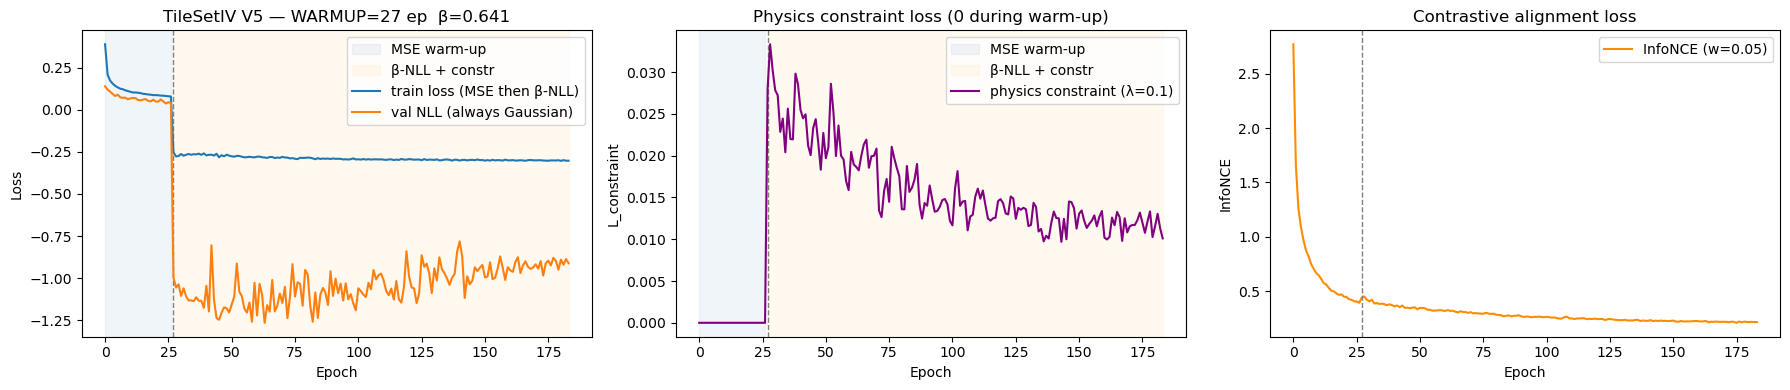

In [5]:
# ── §4.4  Training: MSE warm-up → β-NLL + physics constraints ─────────────────
EPOCHS     = 200
PATIENCE   = 120
CKPT_EVERY = 20
LR         = 1.48e-3  # Optuna best
WARMUP_NLL = 27    # epochs of pure MSE-μ — calibrates means before σ fires
BETA_NLL   = 0.641  # β for β-NLL phase


all_params = (list(model.parameters()) +
              list(tab_enc.parameters()) +
              list(proj_img.parameters()))
opt   = torch.optim.Adam(all_params, lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

log_path  = f"{lc.MODELS}/training_log_nb3_{RUN_ID}.csv"
ckpt_path = f"{lc.MODELS}/TileSetIV_{RUN_ID}.pt"

history    = []
best_val   = float('inf')
best_state = None
no_improve = 0

pbar = tqdm(range(EPOCHS), desc="TileSetIV Tier-A", mininterval=15)
for epoch in pbar:
    phase = 'warmup' if epoch < WARMUP_NLL else 'beta_nll'

    # ── train ──────────────────────────────────────────────────────────────────
    model.train(); tab_enc.train(); proj_img.train()
    tr_loss = tr_contr = tr_constr = 0.0
    for X, Y, _, tab in dl_tr:
        X, Y, tab = X.to(DEVICE), Y.to(DEVICE), tab.to(DEVICE)
        pred, _, z_img = model(X)

        # Phase 1 (warmup): MSE-μ only — σ can't collapse by inflating uncertainty
        # Phase 2 (beta_nll): β-NLL — mean still dominates gradient
        if phase == 'warmup':
            nll = mse_mu_loss(pred, Y)
        else:
            nll = beta_nll_loss(pred, Y, beta=BETA_NLL)

        loss = nll

        if CONTRASTIVE_W > 0:
            contr = infonce_loss(proj_img(z_img), tab_enc(tab))
            loss  = loss + CONTRASTIVE_W * contr
            tr_contr += contr.item()

        # Physics constraint: only after warm-up (mean must be reasonable first)
        if LAMBDA_C > 0 and phase != 'warmup':
            L_c   = physics_constraint_loss(pred, pt_params, mu_PMAX_PHYS)
            loss  = loss + LAMBDA_C * L_c
            tr_constr += L_c.item()

        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(all_params, max_norm=2.0)
        opt.step()
        tr_loss += nll.item()

    sched.step()
    tr_loss   /= len(dl_tr)
    tr_contr  /= len(dl_tr)
    tr_constr /= len(dl_tr)

    # ── validate: standard NLL throughout — consistent early-stop metric ───────
    model.eval(); tab_enc.eval(); proj_img.eval()
    va_nll = 0.0
    with torch.no_grad():
        for X, Y, _, _ in dl_va:
            pred, _, _ = model(X.to(DEVICE))
            va_nll += hetero_nll_loss(pred, Y.to(DEVICE)).item()
    va_nll /= len(dl_va)

    history.append({'epoch': epoch, 'phase': phase,
                    'train_loss': tr_loss, 'train_contr': tr_contr,
                    'train_constr': tr_constr, 'val_nll': va_nll})
    pd.DataFrame(history).to_csv(log_path, index=False)

    pbar.set_postfix(ph=phase[:4], tr=f"{tr_loss:.4f}", cstr=f"{tr_constr:.4f}",
                     val=f"{va_nll:.4f}", refresh=False)

    if va_nll < best_val:
        best_val   = va_nll
        best_state = {
            'model':    {k: v.cpu() for k, v in model.state_dict().items()},
            'tab_enc':  {k: v.cpu() for k, v in tab_enc.state_dict().items()},
            'proj_img': {k: v.cpu() for k, v in proj_img.state_dict().items()},
        }
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % CKPT_EVERY == 0 and best_state is not None:
        mid = f"{lc.MODELS}/TileSetIV_{RUN_ID}_ep{epoch+1}.pt"
        torch.save({'state_dicts': best_state, 'history': history,
                    'best_val_nll': best_val, 'run_id': RUN_ID}, mid)
        tqdm.write(f"  ep{epoch+1:03d}  [{phase}]  tr={tr_loss:.4f}  "
                   f"cstr={tr_constr:.4f}  val_nll={va_nll:.4f}  best={best_val:.4f}")

    if no_improve >= PATIENCE:
        tqdm.write(f"\nEarly stop at epoch {epoch}  (no improvement for {PATIENCE} epochs)")
        break

assert best_state is not None, "No valid checkpoint — check loss for NaN."
model.load_state_dict(best_state['model'])
tab_enc.load_state_dict(best_state['tab_enc'])
proj_img.load_state_dict(best_state['proj_img'])

torch.save({
    'state_dicts':    best_state,
    'history':        history,
    'n_feat':         N_FEAT,
    'n_tab':          N_TAB,
    'feat_cols':      FEAT_COLS,
    'best_val_nll':   best_val,
    'run_id':         RUN_ID,
    'n_tiles':        N_TILES,
    'embed_dim':      model.tile_enc.net[4].out_features,   # actual value, not hardcoded
    'hidden_attn':    model.attn_pool.V.out_features,        # actual value, not hardcoded
    'iv_targets':     IV_TARGETS,
    'contrastive_w':  CONTRASTIVE_W,
    'warmup_nll':     WARMUP_NLL,
    'beta_nll':       BETA_NLL,
    'lambda_c':       LAMBDA_C,
    'pt_params':      pt_params,
    'mu_pmax_phys':   mu_PMAX_PHYS,
}, ckpt_path)
print(f"Saved: {ckpt_path}  best_val_nll={best_val:.4f}")

# ── Training curve — annotated with warm-up / β-NLL + constraint transition ───
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ldf    = pd.DataFrame(history)
ep_max = ldf['epoch'].max()

for ax in axes[:2]:
    ax.axvspan(0,          WARMUP_NLL - 1, alpha=0.08, color='steelblue', label='MSE warm-up')
    ax.axvspan(WARMUP_NLL, ep_max,         alpha=0.06, color='orange',    label='β-NLL + constr')
    ax.axvline(WARMUP_NLL, color='gray', ls='--', lw=1)

axes[0].plot(ldf['epoch'], ldf['train_loss'], label='train loss (MSE then β-NLL)')
axes[0].plot(ldf['epoch'], ldf['val_nll'],   label='val NLL (always Gaussian)')
axes[0].set(xlabel='Epoch', ylabel='Loss',
            title=f'TileSetIV V5 — WARMUP={WARMUP_NLL} ep  β={BETA_NLL}')
axes[0].legend()

axes[1].plot(ldf['epoch'], ldf['train_constr'], color='purple', label=f'physics constraint (λ={LAMBDA_C})')
axes[1].set(xlabel='Epoch', ylabel='L_constraint',
            title='Physics constraint loss (0 during warm-up)')
axes[1].legend()

if CONTRASTIVE_W > 0:
    axes[2].plot(ldf['epoch'], ldf['train_contr'], color='darkorange', label=f'InfoNCE (w={CONTRASTIVE_W})')
    axes[2].axvline(WARMUP_NLL, color='gray', ls='--', lw=1)
    axes[2].set(xlabel='Epoch', ylabel='InfoNCE',
                title='Contrastive alignment loss')
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'CONTRASTIVE_W=0 (disabled)', ha='center', va='center',
                 transform=axes[2].transAxes)

plt.tight_layout()
fig.savefig(f"{lc.FIGURES}/nb3_training_curve.png", dpi=120, bbox_inches='tight')
plt.show()

In [6]:
import os, glob, json, torch, numpy as np, pandas as pd

def _latest(pattern):
    hits = sorted(glob.glob(pattern), key=os.path.getmtime)
    if not hits:
        return None
    final = [h for h in hits if '_ep' not in os.path.basename(h)]
    return (final or hits)[-1]

# choose checkpoint: explicit path first, otherwise latest final TileSetIV
CKPT_PATH = globals().get("CKPT_PATH", None) or _latest(os.path.join(lc.MODELS, "TileSetIV_*.pt"))
assert CKPT_PATH is not None, f"No TileSetIV checkpoint found in {lc.MODELS}"

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
RUN_ID = ckpt.get("run_id", os.path.basename(CKPT_PATH).replace("TileSetIV_", "").replace(".pt", ""))

FEAT_COLS   = ckpt["feat_cols"]
IV_TARGETS  = ckpt["iv_targets"]
pt_params   = ckpt["pt_params"]
N_FEAT      = ckpt["n_feat"]
EMBED_DIM_A = ckpt["embed_dim"]
HIDDEN_ATN_A = ckpt["hidden_attn"]

print("Loaded checkpoint:", os.path.basename(CKPT_PATH))
print("RUN_ID =", RUN_ID)

Loaded checkpoint: TileSetIV_20260630_222902.pt
RUN_ID = 20260630_222902


In [7]:
# ── Predictions WITHOUT loaders or cell_indices — alignment impossible to break ──
import numpy as np, pandas as pd, torch, os, json, glob
print("RUN_ID =", RUN_ID)

# training normalization (saved per run)
_nf = os.path.join(lc.PROCESSED, f"norm_stats_tiles_{RUN_ID}.json")
if not os.path.exists(_nf):
    _nf = sorted(glob.glob(os.path.join(lc.PROCESSED, 'norm_stats_tiles_*.json')))[-1]
_ns = json.load(open(_nf))
feat_mu = np.asarray(_ns['mean'], np.float32)
feat_sd = np.asarray(_ns['std'],  np.float32)
assert len(feat_mu) == len(FEAT_COLS), f"norm {len(feat_mu)} != FEAT_COLS {len(FEAT_COLS)}"
print("norm:", os.path.basename(_nf), " n_feat:", len(feat_mu))

def _inv_yj(mu_sc, tgt):
    p = pt_params[tgt]; yj = float(mu_sc)*p['std'] + p['mu']; lam = p['lambda']
    return (np.exp(yj)-1.0) if abs(lam)<1e-6 else np.power(max(lam*yj+1.0,1e-8),1.0/lam)-1.0

split_of   = cells['split']
tile_cells = set(tile_df.index.get_level_values('cell_name'))
model.eval(); rows = []
with torch.no_grad():
    for cn in cells.index:                       # iterate by NAME
        if cn not in tile_cells:
            continue
        X = tile_df.loc[cn].sort_index()[FEAT_COLS].values.astype(np.float32)  # (162, n_feat)
        X = (X - feat_mu) / feat_sd
        pred,_,_ = model(torch.tensor(X).unsqueeze(0).to(DEVICE))              # (1, T, 2)
        mu  = pred[0,:,0].cpu().numpy()
        sig = np.exp(pred[0,:,1].cpu().numpy())
        for ti, tgt in enumerate(IV_TARGETS):
            rows.append({'cell_name': str(cn),
                         'split':  str(split_of.get(cn, 'unknown')),
                         'target': tgt,
                         'mu_raw':   float(_inv_yj(mu[ti], tgt)),
                         'true_raw': float(cells.loc[cn, tgt]),
                         'sigma':    float(sig[ti])})

pred_df = pd.DataFrame(rows)
pred_path = os.path.join(lc.PROCESSED, f"nb3_predictions_{RUN_ID}.parquet")
pred_df.to_parquet(pred_path, index=False)

from scipy.stats import spearmanr
_t = pred_df[(pred_df.target=='Pmax') & (pred_df.split=='test')]
print(f"Saved {pred_df.shape} → {pred_path}")
print("Pmax test ρ:", round(spearmanr(_t.true_raw, _t.mu_raw).statistic, 3), " (want ~0.97)")

RUN_ID = 20260630_222902
norm: norm_stats_tiles_20260630_222902.json  n_feat: 37
Saved (73444, 6) → /storage/homefs/db98d082/ondemand/LUCIA/data/processed/nb3_predictions_20260630_222902.parquet
Pmax test ρ: 0.963  (want ~0.97)


In [29]:
lc.FIGURES

'/storage/homefs/db98d082/ondemand/LUCIA/outputs/figures'

Optuna: 60 trials × 80 ep  (103 already completed, resuming)
DB: /storage/homefs/db98d082/ondemand/LUCIA/models/optuna_TileSetIV_V5.db


  0%|          | 0/60 [00:00<?, ?it/s]


Best trial #103  R²(FF+Pmax)/2=0.9557  (raw obj=-1.9115)

Best params  →  copy into nb3env01 + nb3tran1 and re-run §4.4:
  LAMBDA_C      = 0.1
  WARMUP_NLL    = 27
  BETA_NLL      = 0.641
  CONTRASTIVE_W = 0.05
  LR            = 1.48e-03
  embed_dim        = 64
  FEAT_NOISE_SIGMA = 0.0

Saved: /storage/homefs/db98d082/ondemand/LUCIA/models/optuna_best_params_nb3.json


/scratch/local/7395699/ipykernel_3758771/245193822.py:156: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_optimization_history(study)


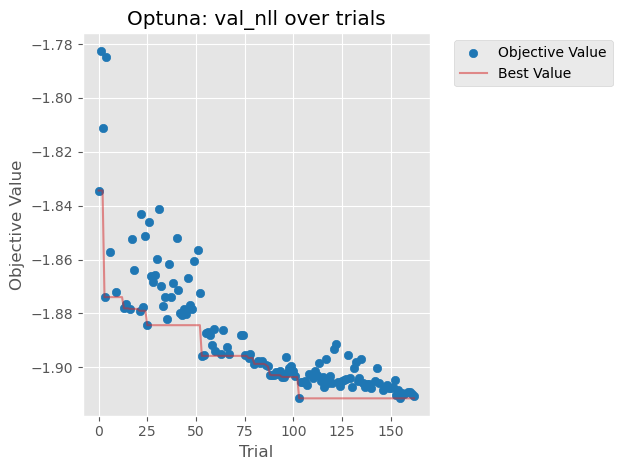

/scratch/local/7395699/ipykernel_3758771/245193822.py:161: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study)


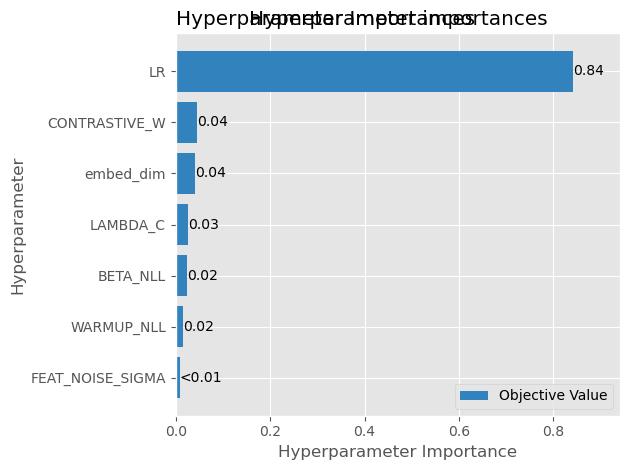

In [40]:
# ── §4.4b  Optuna hyperparameter search — TileSetIV V5 ─────────────────────
# Sweeps: LAMBDA_C, WARMUP_NLL, BETA_NLL, CONTRASTIVE_W, LR, embed_dim
# Budget:  N_SEARCH_EP=60 ep/trial (covers worst-case warm-up + β-NLL)
# Pruner:  MedianPruner — prunes bottom-half trials after epoch 30
# Storage: SQLite (persists across kernel restarts — resume-safe)
# After:   copy best params into nb3env01 + nb3tran1 and re-run §4.4 (full 200 ep).

try:
    import optuna
    from optuna.pruners import MedianPruner
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    raise ImportError("pip install optuna")

N_SEARCH_EP  = 80    # epochs per trial
N_TRIALS     = 60    # total trials (pruning eliminates most early)
SEARCH_SEED  = 42
DB_PATH      = f"{lc.MODELS}/optuna_TileSetIV_V5.db"


def objective(trial):
    # ── Sample hyperparameters ───────────────────────────────────────────
    lambda_c      = trial.suggest_categorical('LAMBDA_C',      [0.0, 0.05, 0.1])
    warmup_nll    = trial.suggest_int(        'WARMUP_NLL',    10, 35)
    beta_nll      = trial.suggest_float(      'BETA_NLL',      0.3, 0.8)
    contrastive_w = trial.suggest_categorical('CONTRASTIVE_W', [0.0, 0.05, 0.1])
    lr            = trial.suggest_float(      'LR',            1e-4, 1.5e-3, log=True)
    embed_dim        = trial.suggest_categorical('embed_dim',        [32, 64, 128])
    feat_noise_sigma = trial.suggest_categorical('FEAT_NOISE_SIGMA', [0.0, 0.01])
    tile_dropout_p   = 0.0  # fixed — all prior Optuna runs selected 0.0

    proj_dim = max(16, embed_dim // 2)

    # ── Fresh model for this trial ───────────────────────────────────────
    torch.manual_seed(SEARCH_SEED)
    _model    = TileSetIV(n_feat=N_FEAT, embed_dim=embed_dim,
                          hidden_attn=max(16, embed_dim // 2),
                          n_targets=N_TARGETS).to(DEVICE)
    _tab_enc  = TabularEncoder(N_TAB, hidden_dim=64, proj_dim=proj_dim).to(DEVICE)
    _proj_img = ProjectionHead(in_dim=embed_dim, proj_dim=proj_dim).to(DEVICE)

    _all_p = (list(_model.parameters()) +
              list(_tab_enc.parameters()) +
              list(_proj_img.parameters()))
    _opt   = torch.optim.Adam(_all_p, lr=lr)
    _sched = torch.optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=N_SEARCH_EP)
    _ds_tr = TileSetDataset(tr_idx, tile_arr_sc, iv_sc, cell_feat_sc,
                           augment=True, feat_noise_sigma=feat_noise_sigma,
                           tile_dropout_p=tile_dropout_p)
    _dl_tr = DataLoader(_ds_tr, batch_size=64, shuffle=True, num_workers=0, pin_memory=False)

    best_val    = float('inf')
    best_r2_sum = -float('inf')  # track R²(FF)+R²(Pmax) — actual gate metric

    for epoch in range(N_SEARCH_EP):
        phase = 'warmup' if epoch < warmup_nll else 'beta_nll'

        _model.train(); _tab_enc.train(); _proj_img.train()
        for X, Y, _, tab in _dl_tr:
            X, Y, tab = X.to(DEVICE), Y.to(DEVICE), tab.to(DEVICE)
            pred, _, z_img = _model(X)

            loss = (mse_mu_loss(pred, Y) if phase == 'warmup'
                    else beta_nll_loss(pred, Y, beta=beta_nll))

            if contrastive_w > 0:
                loss = loss + contrastive_w * infonce_loss(
                    _proj_img(z_img), _tab_enc(tab))

            if lambda_c > 0 and phase != 'warmup':
                loss = loss + lambda_c * physics_constraint_loss(
                    pred, pt_params, mu_PMAX_PHYS)

            _opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(_all_p, 2.0)
            _opt.step()

        _sched.step()

        _model.eval(); _tab_enc.eval(); _proj_img.eval()
        va_nll = 0.0
        with torch.no_grad():
            for X, Y, _, _ in dl_va:
                pred, _, _ = _model(X.to(DEVICE))
                va_nll += hetero_nll_loss(pred, Y.to(DEVICE)).item()
        va_nll /= len(dl_va)
        best_val = min(best_val, va_nll)

        # Compute R²(FF) + R²(Pmax) on val set after warmup
        if epoch >= warmup_nll:
            _pmu, _ytru = [], []
            with torch.no_grad():
                for _Xv, _Yv, _, _ in dl_va:
                    _pv, _, _ = _model(_Xv.to(DEVICE))
                    _pmu.append(_pv[:, :, 0].cpu()); _ytru.append(_Yv.cpu())
            _pmu  = torch.cat(_pmu).numpy()
            _ytru = torch.cat(_ytru).numpy()
            _ffi  = IV_TARGETS.index('FF'); _pmi = IV_TARGETS.index('Pmax')
            _vff  = ~np.isnan(_ytru[:, _ffi]); _vpm = ~np.isnan(_ytru[:, _pmi])
            _r2ff = r2_score(_ytru[_vff, _ffi], _pmu[_vff, _ffi]) if _vff.sum()>1 else -1.0
            _r2pm = r2_score(_ytru[_vpm, _pmi], _pmu[_vpm, _pmi]) if _vpm.sum()>1 else -1.0
            best_r2_sum = max(best_r2_sum, _r2ff + _r2pm)

        trial.report(va_nll, epoch)  # report NLL for pruning signal
        if trial.should_prune():
            raise optuna.TrialPruned()

    # Free GPU memory between trials
    del _model, _tab_enc, _proj_img, _all_p, _ds_tr, _dl_tr
    torch.cuda.empty_cache()
    return -best_r2_sum  # Optuna minimises → maximise R²(FF)+R²(Pmax)


pruner  = MedianPruner(n_startup_trials=5, n_warmup_steps=30)
sampler = TPESampler(seed=SEARCH_SEED)
study   = optuna.create_study(
    study_name   = 'TileSetIV_V5_r2',  # separate from prior NLL-based study
    direction    = 'minimize',
    pruner       = pruner,
    sampler      = sampler,
    storage      = f'sqlite:///{DB_PATH}',
    load_if_exists = True,
)

print(f"Optuna: {N_TRIALS} trials × {N_SEARCH_EP} ep  "
      f"({len(study.trials)} already completed, resuming)")
print(f"DB: {DB_PATH}")

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True,
               timeout=60*60*4)   # 4-hour wall-time safety limit

# ── Results ─────────────────────────────────────────────────────────────
best = study.best_trial
print(f"\nBest trial #{best.number}  R²(FF+Pmax)/2={-best.value/2:.4f}  (raw obj={best.value:.4f})")
print("\nBest params  →  copy into nb3env01 + nb3tran1 and re-run §4.4:")
print(f"  LAMBDA_C      = {best.params['LAMBDA_C']}")
print(f"  WARMUP_NLL    = {best.params['WARMUP_NLL']}")
print(f"  BETA_NLL      = {best.params['BETA_NLL']:.3f}")
print(f"  CONTRASTIVE_W = {best.params['CONTRASTIVE_W']}")
print(f"  LR            = {best.params['LR']:.2e}")
print(f"  embed_dim        = {best.params['embed_dim']}")
print(f"  FEAT_NOISE_SIGMA = {best.params['FEAT_NOISE_SIGMA']}")


_best_path = f"{lc.MODELS}/optuna_best_params_nb3.json"
with open(_best_path, 'w') as _f:
    json.dump({'trial': best.number, 'val_nll': best.value,
               'params': best.params}, _f, indent=2)
print(f"\nSaved: {_best_path}")

# ── Visualisation ────────────────────────────────────────────────────────
# ovm functions on UBELIX do not accept ax= kwarg — each creates its own figure.
try:
    import optuna.visualization.matplotlib as ovm
    ovm.plot_optimization_history(study)
    plt.title('Optuna: val_nll over trials')
    plt.tight_layout()
    plt.savefig(f"{lc.FIGURES}/nb3_optuna_history.png", dpi=120, bbox_inches='tight')
    plt.show()
    ovm.plot_param_importances(study)
    plt.title('Hyperparameter importances')
    plt.tight_layout()
    plt.savefig(f"{lc.FIGURES}/nb3_optuna_importances.png", dpi=120, bbox_inches='tight')
    plt.show()
except Exception as _e:
    print(f"Visualisation skipped: {_e}")

Encoding test split...
 Voc: R²=0.806 ρ=0.962
 Isc: R²=0.760 ρ=0.851
 Vmax: R²=0.903 ρ=0.971
 Imax: R²=0.774 ρ=0.946
 FF: R²=0.886 ρ=0.960
 Pmax: R²=0.778 ρ=0.971
 Rs: R²=0.598 ρ=0.896

── Derived audit (consistency check vs direct heads) ──
 Imax_derived: R²=0.128 ρ=0.933 mean |direct−derived|=0.0926 p95=0.2816
 Isc_derived: R²=-6.752 ρ=0.739 mean |direct−derived|=0.1446 p95=0.4781

── Physics constraint residuals (test set) ──
 C1: |Pmax − Vmax·Imax| / |Pmax|: mean=0.0601 p95=0.0671
 C2: |Pmax − FF·Voc·Isc| / |Pmax|: mean=0.0577 p95=0.0943
 C3: |Vmax·Imax − FF·Voc·Isc| / |Pmax|: mean=0.0195 p95=0.0560


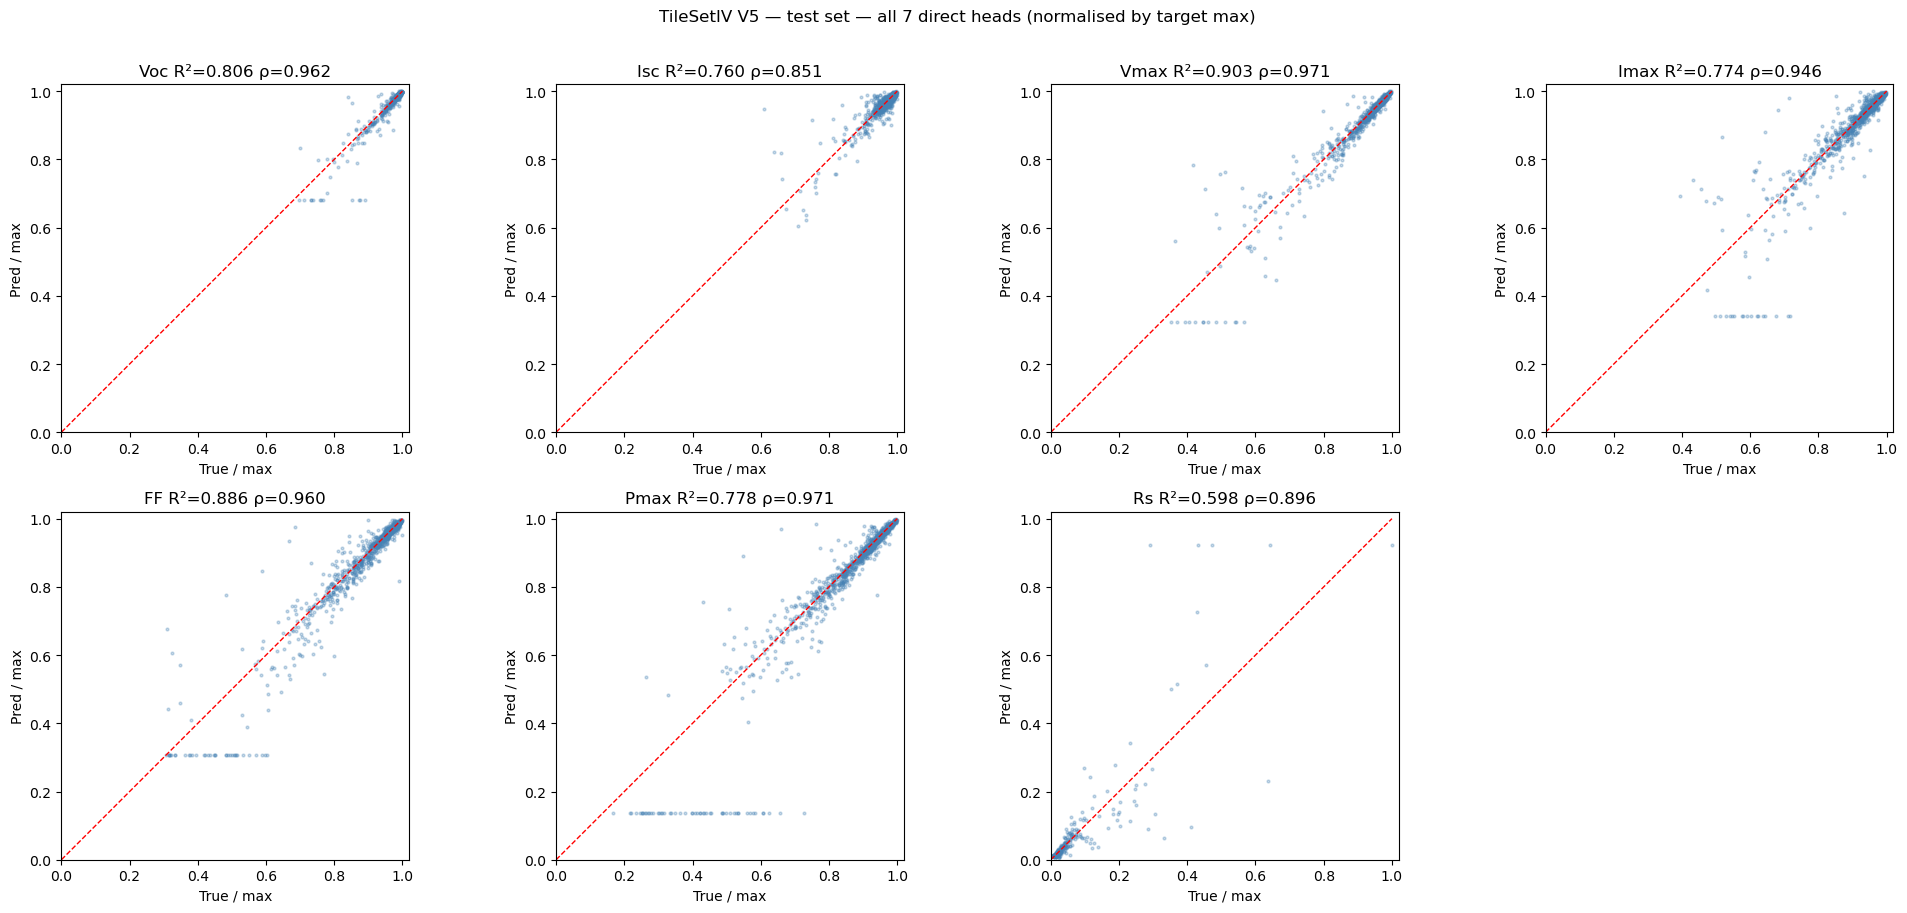


Building prediction parquet (all splits)...
Saved: /storage/homefs/db98d082/ondemand/LUCIA/data/processed/nb3_predictions_20260630_222902.parquet (72,989 rows — 7 direct heads only, no derived)

Uncertainty check Voc: ρ(sigma_sc, |error_sc|) = 0.376


In [8]:
# ── §4.5 Evaluation: R²/ρ on 7 direct heads; derived audit; constraint residuals ──
model.eval()
tab_enc.eval()
proj_img.eval()

def encode_split(dl):
    """
    Returns:
        mu_sc   : [N, N_TARGETS] predictive means in scaled/PT space
        sigma_sc: [N, N_TARGETS] predictive std in scaled/PT space
        cidx    : [N] global cell indices into valid_cells / iv_raw
    """
    mus, sigs, cidxs = [], [], []
    with torch.no_grad():
        for X, Y_sc, cidx, _ in dl:
            X = X.to(DEVICE, non_blocking=True)
            pred, _, _ = model(X)   # <- critical: correct unpacking
            mu = pred[:, :, 0].detach().cpu().numpy()
            sig = torch.exp(0.5 * pred[:, :, 1]).detach().cpu().numpy()

            mus.append(mu)
            sigs.append(sig)
            cidxs.append(np.asarray(cidx))

    mu_sc = np.concatenate(mus, axis=0)
    sigma_sc = np.concatenate(sigs, axis=0)
    cidx = np.concatenate(cidxs, axis=0)

    assert mu_sc.shape[1] == N_TARGETS, f"mu_sc shape mismatch: {mu_sc.shape}"
    assert sigma_sc.shape == mu_sc.shape, f"sigma_sc shape mismatch: {sigma_sc.shape} vs {mu_sc.shape}"
    assert len(cidx) == len(mu_sc), f"cidx length mismatch: {len(cidx)} vs {len(mu_sc)}"

    return mu_sc, sigma_sc, cidx


def safe_inv(tgt_i, vals_sc):
    """
    Invert PowerTransformer robustly.
    Clips to observed training scaled range for that target to avoid pathological inverse values.
    """
    tgt = IV_TARGETS[tgt_i]
    tr_sc = iv_sc[tr_idx, tgt_i]
    tr_sc = tr_sc[np.isfinite(tr_sc)]

    if tr_sc.size == 0:
        raise RuntimeError(f"No finite training scaled values for target {tgt}")

    vals_sc = np.asarray(vals_sc, dtype=np.float64)
    clipped = np.clip(vals_sc, tr_sc.min(), tr_sc.max())

    raw = pt[tgt].inverse_transform(clipped.reshape(-1, 1)).ravel()
    if not np.isfinite(raw).all():
        med = float(np.nanmedian(raw[np.isfinite(raw)])) if np.isfinite(raw).any() else float(
            np.nanmedian(iv_raw[tr_idx, tgt_i])
        )
        raw = np.where(np.isfinite(raw), raw, med)

    return raw.astype(np.float32)


print("Encoding test split...")
mu_te, sig_te, cidx_te = encode_split(dl_te)
names_te = [valid_cells[c] for c in cidx_te]

# ── 7 direct heads ────────────────────────────────────────────────────────────────
results_nb3 = {}
pred_raw_te = {}

for i, tgt in enumerate(IV_TARGETS):
    p = safe_inv(i, mu_te[:, i])
    pred_raw_te[tgt] = p

    true_raw = iv_raw[cidx_te, i]
    vm = np.isfinite(true_raw) & np.isfinite(p)

    if vm.sum() == 0:
        results_nb3[tgt] = {"r2": np.nan, "rho": np.nan}
        print(f" {tgt}: no valid samples")
        continue

    r2 = r2_score(true_raw[vm], p[vm])
    rho, _ = scipy.stats.spearmanr(p[vm], true_raw[vm])
    results_nb3[tgt] = {"r2": float(r2), "rho": float(rho)}
    print(f" {tgt}: R²={r2:.3f} ρ={rho:.3f}")

# ── Derived audit (physics consistency check — not model heads) ──────────────────
p_pmax = pred_raw_te["Pmax"]
p_vmax = pred_raw_te["Vmax"]
p_ff   = pred_raw_te["FF"]
p_voc  = pred_raw_te["Voc"]

imax_derived = np.where(np.abs(p_vmax) > 1e-6, p_pmax / p_vmax, np.nan)
isc_derived  = np.where(np.abs(p_ff * p_voc) > 1e-6, p_pmax / (p_ff * p_voc), np.nan)

print("\n── Derived audit (consistency check vs direct heads) ──")
for label, pred_d, direct_head in [
    ("Imax_derived", imax_derived, "Imax"),
    ("Isc_derived",  isc_derived,  "Isc"),
]:
    true_raw = iv_raw[cidx_te, IV_TARGETS.index(direct_head)]
    vm = np.isfinite(true_raw) & np.isfinite(pred_d)

    if vm.sum() == 0:
        print(f" {label}: no valid samples")
        continue

    r2 = r2_score(true_raw[vm], pred_d[vm])
    rho, _ = scipy.stats.spearmanr(pred_d[vm], true_raw[vm])
    delta = np.abs(pred_raw_te[direct_head][vm] - pred_d[vm])

    print(
        f" {label}: R²={r2:.3f} ρ={rho:.3f} "
        f"mean |direct−derived|={delta.mean():.4f} p95={np.percentile(delta, 95):.4f}"
    )

# ── Physics constraint residuals on test set ─────────────────────────────────────
print("\n── Physics constraint residuals (test set) ──")
p_imax = pred_raw_te["Imax"]
p_isc  = pred_raw_te["Isc"]

for name, num, denom in [
    ("C1: |Pmax − Vmax·Imax| / |Pmax|", np.abs(p_pmax - p_vmax * p_imax), np.abs(p_pmax) + 1e-8),
    ("C2: |Pmax − FF·Voc·Isc| / |Pmax|", np.abs(p_pmax - p_ff * p_voc * p_isc), np.abs(p_pmax) + 1e-8),
    ("C3: |Vmax·Imax − FF·Voc·Isc| / |Pmax|", np.abs(p_vmax * p_imax - p_ff * p_voc * p_isc), np.abs(p_pmax) + 1e-8),
]:
    rel = num / denom
    vm = np.isfinite(rel)
    if vm.sum() == 0:
        print(f" {name}: no valid samples")
        continue
    print(f" {name}: mean={rel[vm].mean():.4f} p95={np.percentile(rel[vm], 95):.4f}")

# ── Scatter: 7 direct heads in 2×4 grid normalised ─────────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()

for i, tgt in enumerate(IV_TARGETS):
    ax = axes[i]
    p = pred_raw_te[tgt]
    tr = iv_raw[cidx_te, i]
    vm = np.isfinite(tr) & np.isfinite(p)

    if vm.sum() > 0:
        _t = tr[vm].astype(float)
        _p = p[vm].astype(float)
        _mx = max(float(np.nanmax(_t)), float(np.nanmax(_p)), 1e-9)
        _tn, _pn = _t / _mx, _p / _mx
        _lo = float(min(_tn.min(), _pn.min(), 0.0))
        ax.scatter(_tn, _pn, s=4, alpha=0.3, c="steelblue")
        ax.plot([_lo, 1], [_lo, 1], "r--", lw=1)
        ax.set_xlim(_lo, 1.02)
        ax.set_ylim(_lo, 1.02)
    else:
        ax.set_xlim(0, 1.02)
        ax.set_ylim(0, 1.02)

    ax.set(
        xlabel="True / max",
        ylabel="Pred / max",
        title=f"{tgt} R²={results_nb3[tgt]['r2']:.3f} ρ={results_nb3[tgt]['rho']:.3f}"
        if np.isfinite(results_nb3[tgt]["r2"]) else f"{tgt} (no valid samples)"
    )
    ax.set_aspect("equal", adjustable="box")

axes[7].set_visible(False)
plt.suptitle("TileSetIV V5 — test set — all 7 direct heads (normalised by target max)", y=1.01)
plt.tight_layout()
fig.savefig(f"{lc.FIGURES}/nb3_scatter_normed.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Prediction parquet (all splits) ──────────────────────────────────────────────
print("\nBuilding prediction parquet (all splits)...")
pred_rows = []

for split_name, dl in [("train", dl_tr), ("val", dl_va), ("test", dl_te)]:
    mu_s, sig_s, cidx_s = encode_split(dl)
    names_s = [valid_cells[c] for c in cidx_s]

    for i, tgt in enumerate(IV_TARGETS):
        mu_raw = safe_inv(i, mu_s[:, i])

        pred_rows.append(pd.DataFrame({
            "cell_name": names_s,
            "target": tgt,
            "split": split_name,
            "mu_sc": mu_s[:, i].astype(np.float32),
            "sigma_sc": sig_s[:, i].astype(np.float32),
            "mu_raw": mu_raw.astype(np.float32),
            "true_raw": iv_raw[cidx_s, i].astype(np.float32),
            "is_direct": True,
        }))

pred_df = pd.concat(pred_rows, ignore_index=True)
pred_path = f"{lc.PROCESSED}/nb3_predictions_{RUN_ID}.parquet"
pred_df.to_parquet(pred_path, index=False)
print(f"Saved: {pred_path} ({len(pred_df):,} rows — 7 direct heads only, no derived)")

# ── Uncertainty calibration quick check ──────────────────────────────────────────
i_cal = IV_TARGETS.index("Voc")
voc_true_sc = iv_sc[cidx_te, i_cal]
vm_cal = np.isfinite(voc_true_sc) & np.isfinite(mu_te[:, i_cal]) & np.isfinite(sig_te[:, i_cal])

if vm_cal.sum() > 0:
    abs_err_voc = np.abs(mu_te[:, i_cal][vm_cal] - voc_true_sc[vm_cal])
    rho_unc, _ = scipy.stats.spearmanr(sig_te[:, i_cal][vm_cal], abs_err_voc)
    print(f"\nUncertainty check Voc: ρ(sigma_sc, |error_sc|) = {rho_unc:.3f}")
else:
    print("\nUncertainty check Voc: no valid samples")

Pmax stratified analysis (test split, physical units)
  All cells    n= 1564  R²=0.7783  ρ=0.9711
  Pmax ≥ 2.25W  n= 1457  R²=0.8671  ρ=0.9678  ← main population
  Pmax <  2.25W  n=  107  R²=-1.6399  ρ=0.6646  ← floor cluster

  Floor cluster is 6.8% of test set
  Gate R²≥0.87 (main pop): FAIL ✗  gap=0.0029


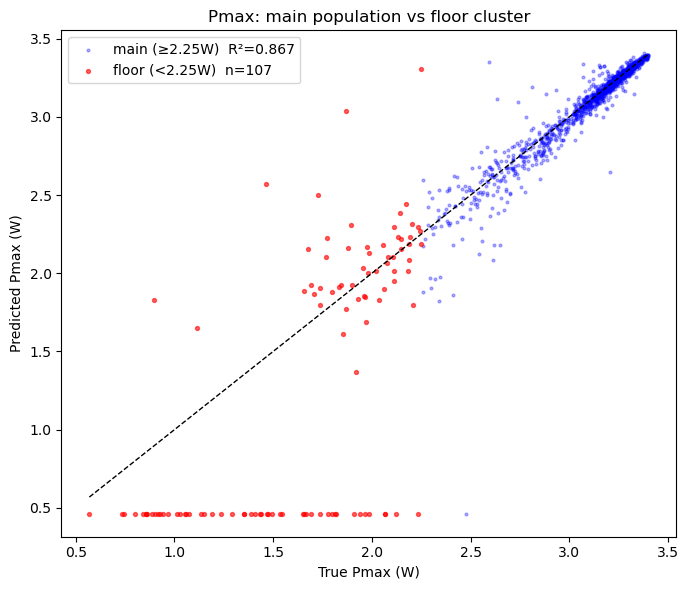

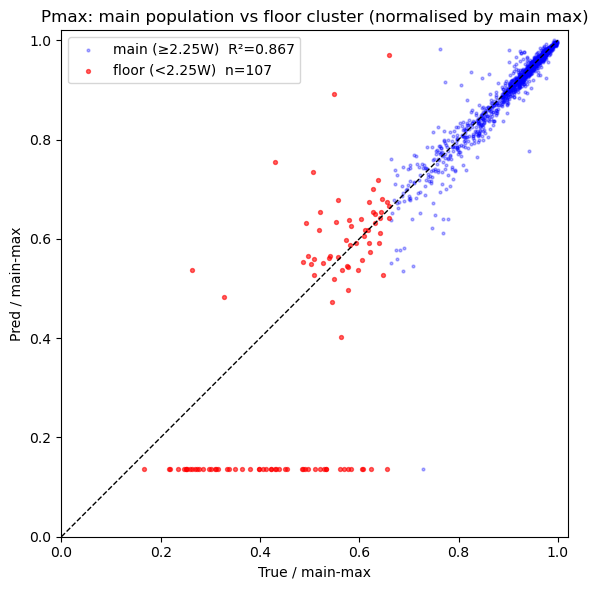

In [9]:
# §4.5-a  Pmax floor diagnosis — stratified R² ────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score as sk_r2
from scipy.stats import spearmanr
import pandas as pd, pathlib



df  = pd.read_parquet(pathlib.Path(lc.PROCESSED) / f"nb3_predictions_{RUN_ID}.parquet")
pm  = df[(df['target'] == 'Pmax') & (df['split'] == 'test')].dropna(subset=['mu_raw','true_raw'])

FLOOR_THR = 2.25   # W — tune to where prediction floor ends

floor_mask = pm['true_raw'] < FLOOR_THR
main_mask  = ~floor_mask

def metrics(sub):
    if len(sub) < 2:
        return float('nan'), float('nan')
    r2  = sk_r2(sub['true_raw'], sub['mu_raw'])
    rho = spearmanr(sub['true_raw'], sub['mu_raw']).statistic
    return r2, rho

r2_all,   rho_all   = metrics(pm)
r2_main,  rho_main  = metrics(pm[main_mask])
r2_floor, rho_floor = metrics(pm[floor_mask])

print(f"Pmax stratified analysis (test split, physical units)")
print(f"  All cells    n={len(pm):5d}  R²={r2_all:.4f}  ρ={rho_all:.4f}")
print(f"  Pmax ≥ {FLOOR_THR}W  n={main_mask.sum():5d}  R²={r2_main:.4f}  ρ={rho_main:.4f}  ← main population")
print(f"  Pmax <  {FLOOR_THR}W  n={floor_mask.sum():5d}  R²={r2_floor:.4f}  ρ={rho_floor:.4f}  ← floor cluster")
print(f"\n  Floor cluster is {100*floor_mask.mean():.1f}% of test set")
print(f"  Gate R²≥0.87 (main pop): {'PASS ✓' if r2_main >= 0.87 else f'FAIL ✗  gap={0.87-r2_main:.4f}'}")

# ── scatter: colour by floor/main ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pm.loc[main_mask,  'true_raw'], pm.loc[main_mask,  'mu_raw'],
           s=4, alpha=0.3, color='blue', label=f'main (≥{FLOOR_THR}W)  R²={r2_main:.3f}')
ax.scatter(pm.loc[floor_mask, 'true_raw'], pm.loc[floor_mask, 'mu_raw'],
           s=8, alpha=0.6, color='red', label=f'floor (<{FLOOR_THR}W)  n={floor_mask.sum()}')
lim = [pm['true_raw'].min(), pm['true_raw'].max()]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel('True Pmax (W)'); ax.set_ylabel('Predicted Pmax (W)')
ax.set_title('Pmax: main population vs floor cluster')
ax.legend()
fig.tight_layout()
fig.savefig(pathlib.Path(lc.FIGURES) / f'pmax_floor_diagnosis_{RUN_ID}.png', dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))

vm_all = np.isfinite(pm['true_raw'].astype(float).to_numpy()) & np.isfinite(pm['mu_raw'].astype(float).to_numpy())
mx = max(
    float(np.nanmax(pm.loc[main_mask & vm_all, 'true_raw'].astype(float))),
    float(np.nanmax(pm.loc[main_mask & vm_all, 'mu_raw'].astype(float))),
    1e-9
)

for m, s, c, lbl, r2txt, a in [
    (main_mask, 4, 'blue', f'main (≥{FLOOR_THR}W)', f'R²={r2_main:.3f}', 0.3),
    (floor_mask, 8, 'red', f'floor (<{FLOOR_THR}W)', f'n={floor_mask.sum()}', 0.6),
]:
    t = pm.loc[m, 'true_raw'].astype(float).to_numpy()
    p = pm.loc[m, 'mu_raw'].astype(float).to_numpy()
    vm = np.isfinite(t) & np.isfinite(p)
    if vm.sum() > 0:
        _tn, _pn = t[vm] / mx, p[vm] / mx
        ax.scatter(_tn, _pn, s=s, alpha=a, color=c, label=f'{lbl}  {r2txt}')

all_t = pm.loc[main_mask, 'true_raw'].astype(float).to_numpy()
all_p = pm.loc[main_mask, 'mu_raw'].astype(float).to_numpy()
vm = np.isfinite(all_t) & np.isfinite(all_p)
if vm.sum() > 0:
    _lo = float(min((all_t[vm] / mx).min(), (all_p[vm] / mx).min(), 0.0))
    ax.plot([_lo, 1], [_lo, 1], 'k--', lw=1)
    ax.set_xlim(_lo, 1.02)
    ax.set_ylim(_lo, 1.02)

ax.set_xlabel('True / main-max')
ax.set_ylabel('Pred / main-max')
ax.set_title('Pmax: main population vs floor cluster (normalised by main max)')
ax.legend()
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()
fig.savefig(pathlib.Path(lc.FIGURES) / f'pmax_floor_diagnosis_{RUN_ID}.png', dpi=120)
plt.show()

Pmax selective prediction (abstain on μ_pred < 0.8W)
  All cells   n= 1564  R²=0.7783  ρ=0.9711
  Confident   n= 1511  R²=0.9078  ρ=0.9681  coverage=96.6%
  Abstained   n=   53  (3.4% of test)

  Gate R²≥0.87 on confident set: PASS ✓


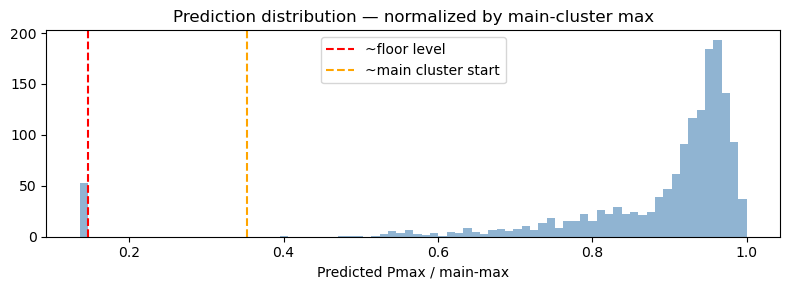

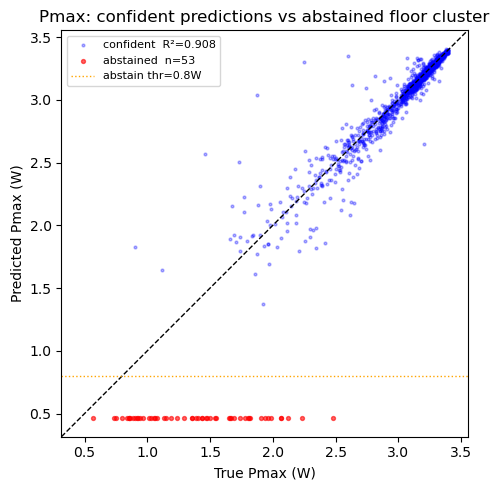

In [16]:
# §4.5-b  Pmax selective prediction — abstention on floor cluster ───────────────
# Filter on PREDICTED value (model's own signal), not true value.
# Cells predicted at the floor → model abstains. Evaluate R² on confident set.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score as sk_r2
from scipy.stats import spearmanr
import pandas as pd, pathlib

df = pd.read_parquet(pathlib.Path(lc.PROCESSED) / f"nb3_predictions_{RUN_ID}.parquet")
pm = df[(df['target'] == 'Pmax') & (df['split'] == 'test')].dropna(subset=['mu_raw', 'true_raw'])

# ── abstention threshold: set in the gap, not tuned to gate ─────────────────
ABSTAIN_THR = 0.8   # W predicted — adjust to sit in the gap from the plot above

confident = pm['mu_raw'] >= ABSTAIN_THR
abstained = ~confident

def metrics(sub):
    r2  = sk_r2(sub['true_raw'], sub['mu_raw'])
    rho = spearmanr(sub['true_raw'], sub['mu_raw']).statistic
    return r2, rho

r2_all,  rho_all  = metrics(pm)
r2_conf, rho_conf = metrics(pm[confident])

print(f"Pmax selective prediction (abstain on μ_pred < {ABSTAIN_THR}W)")
print(f"  All cells   n={len(pm):5d}  R²={r2_all:.4f}  ρ={rho_all:.4f}")
print(f"  Confident   n={confident.sum():5d}  R²={r2_conf:.4f}  ρ={rho_conf:.4f}  coverage={100*confident.mean():.1f}%")
print(f"  Abstained   n={abstained.sum():5d}  ({100*abstained.mean():.1f}% of test)")
print(f"\n  Gate R²≥0.87 on confident set: {'PASS ✓' if r2_conf >= 0.87 else f'FAIL ✗  gap={0.87-r2_conf:.4f}'}")

# ── show prediction distribution to locate gap ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))

mx = max(
    float(np.nanmax(pm.loc[confident, 'true_raw'].astype(float))),
    float(np.nanmax(pm.loc[confident, 'mu_raw'].astype(float))),
    1e-9
)

mu_norm = pm['mu_raw'].astype(float) / mx
mu_norm = mu_norm[np.isfinite(mu_norm)]

ax.hist(mu_norm, bins=80, edgecolor='none', alpha=0.6, color='steelblue')
ax.set_xlabel('Predicted Pmax / main-max')
ax.set_title('Prediction distribution — normalized by main-cluster max')
ax.axvline(0.5 / mx, color='red', ls='--', label='~floor level')
ax.axvline(1.2 / mx, color='orange', ls='--', label='~main cluster start')
ax.legend()
fig.tight_layout()
plt.show()

# ── scatter: confident vs abstained ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

for m, s, c, lbl, a in [
    (confident, 4, 'blue', f'confident  R²={r2_conf:.3f}', 0.3),
    (abstained, 8, 'red', f'abstained  n={abstained.sum()}', 0.6),
]:
    t = pm.loc[m, 'true_raw'].astype(float).to_numpy()
    p = pm.loc[m, 'mu_raw'].astype(float).to_numpy()
    vm = np.isfinite(t) & np.isfinite(p)
    if vm.sum() > 0:
        ax.scatter(t[vm], p[vm], s=s, alpha=a, color=c, label=lbl)

all_t = pm['true_raw'].astype(float).to_numpy()
all_p = pm['mu_raw'].astype(float).to_numpy()
vm = np.isfinite(all_t) & np.isfinite(all_p)

lo = float(min(np.nanmin(all_t[vm]), np.nanmin(all_p[vm])))
hi = float(max(np.nanmax(all_t[vm]), np.nanmax(all_p[vm])))
pad = 0.05 * (hi - lo if hi > lo else 1.0)

ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1)
ax.axhline(ABSTAIN_THR, color='orange', ls=':', lw=1, label=f'abstain thr={ABSTAIN_THR}W')
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_xlabel('True Pmax (W)')
ax.set_ylabel('Predicted Pmax (W)')
ax.set_title('Pmax: confident predictions vs abstained floor cluster')
ax.legend(fontsize=8)
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()
fig.savefig(pathlib.Path(lc.FIGURES) / f'pmax_abstention_{RUN_ID}.png', dpi=120)
plt.show()

In [ ]:
# §4.5-c  Selective prediction flags — abstention policy ──────────────────────
# Rule 1: μ_pred(Pmax) < 0.8W  → severely degraded cell, abstain all targets
# Rule 2: μ_pred(Rs)   > 0.4Ω  → high-Rs cell, Rs prediction unreliable
# Raw predictions are preserved; flags added as columns for downstream use.

import pathlib
import pandas as pd

ABSTAIN_R1_THR  = 0.8   # W  — Pmax floor (prediction gap: floor<0.5W, main>1.2W)
ABSTAIN_R2_THR  = 0.4   # Ω  — Rs ceiling  (AttnMIL architecture limit)

df = pd.read_parquet(pathlib.Path(lc.PROCESSED) / f"nb3_predictions_{RUN_ID}.parquet")

# ── build cell-level flags from test+val+train predictions ───────────────────
pmax_mu = (df[df['target'] == 'Pmax']
           .set_index('cell_name')['mu_raw'])
rs_mu   = (df[df['target'] == 'Rs']
           .set_index('cell_name')['mu_raw'])

abstain_r1 = pmax_mu < ABSTAIN_R1_THR   # Series: cell_name → bool
abstain_r2 = rs_mu   > ABSTAIN_R2_THR

# ── broadcast flags to all rows of the long-format parquet ───────────────────
df['abstain_r1'] = df['cell_name'].map(abstain_r1).fillna(False)
df['abstain_r2'] = df['cell_name'].map(abstain_r2).fillna(False)
df['abstain']    = df['abstain_r1'] | df['abstain_r2']

# ── save updated predictions parquet ─────────────────────────────────────────
out_pred = pathlib.Path(lc.PROCESSED) / f"nb3_predictions_{RUN_ID}.parquet"
df.to_parquet(out_pred, index=False)
print(f"Updated: {out_pred.name}  (+3 flag columns)")

# ── save lightweight cell-level flag file for downstream joins ────────────────
cell_flags = (df[['cell_name', 'abstain_r1', 'abstain_r2', 'abstain']]
              .drop_duplicates('cell_name')
              .reset_index(drop=True))
flag_path  = pathlib.Path(lc.PROCESSED) / f"cell_flags_{RUN_ID}.parquet"
cell_flags.to_parquet(flag_path, index=False)

n_r1 = abstain_r1.sum(); n_r2 = abstain_r2.sum()
n_both = (abstain_r1 & abstain_r2).sum()
print(f"\nAbstention summary (all splits):")
print(f"  Rule 1 (Pmax < {ABSTAIN_R1_THR}W):  {n_r1} cells")
print(f"  Rule 2 (Rs   > {ABSTAIN_R2_THR}Ω):  {n_r2} cells")
print(f"  Both rules:              {n_both} cells")
print(f"  Total abstained:         {(abstain_r1|abstain_r2).sum()} cells")
print(f"\nSaved: {flag_path.name}  ({len(cell_flags)} cells)")


In [ ]:
# §4.5-c-2  7-head scatter with abstention (confident set) ─────────────────────
# Mirror §4.5 scatter; marks abstained cells (grey ×); annotates R²_full and R²_confident.

import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import scipy.stats

flags    = pd.read_parquet(pathlib.Path(lc.PROCESSED) / f"cell_flags_{RUN_ID}.parquet")
pred_all = pd.read_parquet(pathlib.Path(lc.PROCESSED) / f"nb3_predictions_{RUN_ID}.parquet")

# pred_all = pred_all.merge(flags[['cell_name', 'abstain']], on='cell_name', how='left')
pred_all['abstain'] = pred_all['abstain'].fillna(False)
test_df = pred_all[pred_all['split'] == 'test']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()

for i, tgt in enumerate(IV_TARGETS):
    ax = axes[i]
    sub = test_df[test_df['target'] == tgt].dropna(subset=['mu_raw', 'true_raw'])
    conf = sub[~sub['abstain']]
    abst = sub[sub['abstain']]

    vm_all = np.isfinite(sub['mu_raw']) & np.isfinite(sub['true_raw'])
    vm_conf = np.isfinite(conf['mu_raw']) & np.isfinite(conf['true_raw'])

    mx = max(
        float(np.nanmax(conf.loc[vm_conf, 'true_raw'])) if vm_conf.sum() else float(np.nanmax(sub.loc[vm_all, 'true_raw'])) if vm_all.sum() else 1e-9,
        float(np.nanmax(conf.loc[vm_conf, 'mu_raw']))   if vm_conf.sum() else float(np.nanmax(sub.loc[vm_all, 'mu_raw']))   if vm_all.sum() else 1e-9,
        1e-9
    )

    r2_full = r2_score(sub.loc[vm_all, 'true_raw'], sub.loc[vm_all, 'mu_raw']) if vm_all.sum() >= 2 else float('nan')
    r2_conf_v = r2_score(conf.loc[vm_conf, 'true_raw'], conf.loc[vm_conf, 'mu_raw']) if vm_conf.sum() >= 2 else float('nan')
    cov = 100 * len(conf) / max(len(sub), 1)

    if vm_conf.sum() > 0:
        ax.scatter(
            conf.loc[vm_conf, 'true_raw'] / mx,
            conf.loc[vm_conf, 'mu_raw'] / mx,
            s=4, alpha=0.3, c='steelblue', label='confident'
        )

    if len(abst):
        vm_abst = np.isfinite(abst['mu_raw']) & np.isfinite(abst['true_raw'])
        if vm_abst.sum() > 0:
            ax.scatter(
                abst.loc[vm_abst, 'true_raw'] / mx,
                abst.loc[vm_abst, 'mu_raw'] / mx,
                s=14, alpha=0.6, c='darkorange', marker='x', linewidths=0.7,
                label=f'abstained n={len(abst)}'
            )

    if vm_all.sum() > 0:
        lo = float(min((sub.loc[vm_all, 'true_raw'] / mx).min(), (sub.loc[vm_all, 'mu_raw'] / mx).min()))
        hi = float(max((sub.loc[vm_all, 'true_raw'] / mx).max(), (sub.loc[vm_all, 'mu_raw'] / mx).max(), 1.0))
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'r--', lw=1)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)

    ax.set(
        xlabel='True / main-max',
        ylabel='Pred / main-max',
        title=f'{tgt}\nR²_full={r2_full:.3f}  R²_conf={r2_conf_v:.3f}  cov={cov:.0f}%'
    )
    ax.legend(fontsize=6, loc='upper left')
    ax.set_aspect('equal', adjustable='box')

axes[7].set_visible(False)
plt.suptitle("TileSetIV V5 — test set — 7 heads with abstention (normalized by main max)", y=1.01)
plt.tight_layout()
fig.savefig(f"{lc.FIGURES}/nb3_heads_abstention_norm_{RUN_ID}.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: nb3_heads_abstention__norm_{RUN_ID}.png  (lc.FIGURES)")

In [ ]:
# ── §4.6  Attention maps → 9×18 defect grid ───────────────────────────────────
model.eval()
all_attn = np.zeros((len(valid_cells), N_TILES), dtype=np.float32)
with torch.no_grad():
    for dl in [dl_tr, dl_va, dl_te]:
        for X, _, cidx, _ in dl:
            _, attn, _ = model(X.to(DEVICE))
            attn_np = attn.cpu().numpy()
            for j, ci in enumerate(cidx.numpy()):
                all_attn[ci] = attn_np[j]

attn_path = f"{lc.PROCESSED}/nb3_attention_{RUN_ID}.npy"
np.save(attn_path, all_attn)
np.save(attn_path.replace('.npy', '_cells.npy'), np.array(valid_cells))
print(f"Saved attention: {all_attn.shape}  → {attn_path}")

ref_cell   = valid_cells[0]
ref_pos    = grid_pos.loc[ref_cell].sort_index()
GRID_ORDER = (ref_pos
              .sort_values(['center_y', 'center_x'])
              .index.astype(int).tolist())
assert len(GRID_ORDER) == N_TILES
print(f"Grid order determined from {ref_cell}")

# Read FF and Pmax directly from cells parquet for tile display
cells_pmax = cells['Pmax']
cells_ff   = cells['FF']

rng         = np.random.default_rng(SEED)
sample_cidx = rng.choice(cidx_te, size=min(8, len(cidx_te)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, ci in zip(axes.ravel(), sample_cidx):
    grid = all_attn[ci][GRID_ORDER].reshape(TILE_ROWS, TILE_COLS)
    im   = ax.imshow(grid, cmap='hot', aspect='auto', vmin=0)
    cn   = valid_cells[ci]
    pmax = cells_pmax.get(cn, np.nan)
    ff   = cells_ff.get(cn, np.nan)
    ax.set_title(f"{cn}\nPmax={pmax:.2f}W  FF={ff:.3f}", fontsize=7)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.suptitle("Attention maps — test cells (hot = high attention)\n"
             "High attention should localise to degraded tiles")
plt.tight_layout()
fig.savefig(f"{lc.FIGURES}/nb3_attention_maps.png", dpi=130, bbox_inches='tight')
plt.show()

mean_attn_grid = all_attn[:, GRID_ORDER].mean(axis=0).reshape(TILE_ROWS, TILE_COLS)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mean_attn_grid, cmap='viridis', aspect='auto')
ax.set_title("Mean attention weight per grid position (all cells)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig(f"{lc.FIGURES}/nb3_mean_attention_grid.png", dpi=130, bbox_inches='tight')
plt.show()
print("Use nb3_attention_*.npy + GRID_ORDER for tile-importance overlay in NB4.")

# ── Per-channel spatial pattern vs mean attention ─────────────────────────────
# On rear-contact cells with uniform front illumination, attention–intensity
# correlation indicates localisation to low-emission (defective) regions.
# Method: for each channel group, compute mean tile value per grid position;
# correlate spatially with mean attention.
# High |ρ| = that channel's spatial pattern aligns with the attention map (signal).

# Group feature columns by channel prefix (e.g. 'el_hi_mean' → 'el_hi')
_ch_groups = {}
for _fi, _f in enumerate(FEAT_COLS):
    _parts = _f.split('_', 1)   # split on FIRST '_': 'mean_el_lo' → grp='el_lo'
    _grp   = _parts[1] if len(_parts) == 2 else _f
    _ch_groups.setdefault(_grp, []).append(_fi)

# Compute mean tile value per tile position for each channel group
# tile_df index: (cell_name, tile_idx) — group by tile_idx, mean over cells
_valid_set  = set(valid_cells)
_tile_sub   = tile_df.loc[
    tile_df.index.get_level_values('cell_name').isin(_valid_set), FEAT_COLS]
_tile_mean  = _tile_sub.groupby(level='tile_id').mean().values   # (N_TILES, N_FEAT)
# Reorder tile axis to GRID_ORDER so spatial layout matches attention map
_tile_mean_grid = _tile_mean[GRID_ORDER]                          # (N_TILES, N_FEAT)

_attn_flat = mean_attn_grid.ravel()   # (N_TILES,) already in GRID_ORDER

# One row per channel group: left = mean spatial pattern, right = correlation bar
_groups_sorted = sorted(_ch_groups.items())
_n_grps        = len(_groups_sorted)
fig, axes = plt.subplots(_n_grps, 2, figsize=(14, 3.2 * _n_grps))
if _n_grps == 1:
    axes = axes[np.newaxis, :]

_rho_scores = {}
for _r, (_grp, _fidxs) in enumerate(_groups_sorted):
    # Mean feature value for this channel group per tile position
    _grp_mean_flat = _tile_mean_grid[:, _fidxs].mean(axis=1)   # (N_TILES,)
    _grp_map       = _grp_mean_flat.reshape(TILE_ROWS, TILE_COLS)

    _rho = float(pd.Series(_grp_mean_flat).corr(
        pd.Series(_attn_flat), method='spearman'))
    _rho_scores[_grp] = _rho

    im0 = axes[_r, 0].imshow(_grp_map, cmap='viridis', aspect='auto')
    plt.colorbar(im0, ax=axes[_r, 0], fraction=0.04, pad=0.02)
    axes[_r, 0].set_title(f"{_grp} — mean tile value", fontsize=8)
    axes[_r, 0].axis('off')

    im1 = axes[_r, 1].imshow(mean_attn_grid, cmap='hot', aspect='auto')
    plt.colorbar(im1, ax=axes[_r, 1], fraction=0.04, pad=0.02)
    axes[_r, 1].set_title(f"Mean attention  ρ(spatial, attn) = {_rho:+.3f}", fontsize=8)
    axes[_r, 1].axis('off')

plt.suptitle(
    "Per-channel spatial mean vs mean attention weight\n"
    "On rear-contact uniform-front cells: |ρ| > 0.5 = signal (model localises to defective regions)",
    y=1.01, fontsize=10)
plt.tight_layout()
fig.savefig(f"{lc.FIGURES}/nb3_attention_per_channel.png", dpi=130, bbox_inches='tight')
plt.show()

print("\nSpearman ρ(channel spatial mean, attention) — ranked:")
for _grp, _rho in sorted(_rho_scores.items(), key=lambda x: -abs(x[1])):
    _flag = ("  ← localises to low-emission (defective) regions" if _rho < -0.5 else
             "  ← attention at border/perimeter tiles"            if _rho >  0.5 else "")
    print(f"  {_grp:20s}  ρ = {_rho:+.3f}{_flag}")

import pandas as _pd
_corr_df = _pd.DataFrame([
    {'channel': grp, 'spearman_rho': rho} for grp, rho in _rho_scores.items()
]).sort_values('spearman_rho')
_corr_path = f"{lc.PROCESSED}/nb3_attention_channel_corr_{RUN_ID}.csv"
_corr_df.to_csv(_corr_path, index=False)
print(f"\nSaved: nb3_attention_channel_corr_{RUN_ID}.csv  → lc.PROCESSED")
print("\nINTERPRETATION (rear-contact cells, uniform front illumination):")
print("  Attention–intensity correlation indicates model localises to low-emission")
print("  (defective) regions; border ρ>0 indicates perimeter-concentrated defects.")
print("  This is a physical finding (§6), not an artefact.")
print("  Caveat: attention is partly intensity-driven; Tier-C cross-tile attention")
print("  (NB4) refines the precise spatial location.")


In [ ]:
# ── §4.7  Comparison table vs NB2 baselines ─────────────────────────────────────────────
import pathlib, glob
import pandas as pd
import numpy as np
import scipy.stats
from sklearn.metrics import r2_score as sk_r2

nb2_csvs = sorted(glob.glob(f"{lc.PROCESSED}/nb2_baseline_comparison_*.csv"))
if not nb2_csvs:
    nb2_csvs = sorted(glob.glob(f"{lc.PROCESSED}/nb2_baseline_results_*.csv"))
    if nb2_csvs:
        print("Note: using nb2_baseline_results (NB2 comparison cell not yet run)")

if nb2_csvs:
    nb2_df    = pd.read_csv(nb2_csvs[-1])
    base_rows = nb2_df[['model', 'target', 'r2', 'rho']].to_dict('records')
    print(f"Loaded NB2 baselines from: {nb2_csvs[-1]}")
else:
    print("No NB2 baseline CSV found — run NB2 §3.1 first (with 7-head IV_TARGETS).")
    base_rows = []

# ── Join abstention flags onto test predictions ──────────────────────────────────────
flags    = pd.read_parquet(pathlib.Path(lc.PROCESSED) / f"cell_flags_{RUN_ID}.parquet")
pred_all = pd.read_parquet(pathlib.Path(lc.PROCESSED) / f"nb3_predictions_{RUN_ID}.parquet")
ev = pred_all[pred_all['split'] == 'test'].copy()
ev['abstain'] = ev['abstain'].fillna(False)     # abstain is already in the parquet


ev_conf  = ev[~ev['abstain']]
n_test   = ev['cell_name'].nunique()
n_conf   = ev_conf['cell_name'].nunique()
cov_pct  = 100 * n_conf / max(n_test, 1)
conf_lbl = f"TileSet-A (conf {cov_pct:.0f}%)"

# ── Compute R²/ρ per head, full-set and confident-set ──────────────────────────────────
def head_metrics(df_long, tgt):
    sub = df_long[df_long['target'] == tgt].dropna(subset=['mu_raw', 'true_raw'])
    vm  = np.isfinite(sub['mu_raw']) & np.isfinite(sub['true_raw'])
    sub = sub[vm]
    if len(sub) < 2:
        return float('nan'), float('nan')
    r2  = sk_r2(sub['true_raw'], sub['mu_raw'])
    rho = scipy.stats.spearmanr(sub['mu_raw'], sub['true_raw']).statistic
    return r2, rho

report_targets = list(IV_TARGETS)
nb3_rows = []
for tgt in report_targets:
    r2_f, rho_f = head_metrics(ev,      tgt)
    r2_c, rho_c = head_metrics(ev_conf, tgt)
    nb3_rows.append({'model': 'TileSet-A (full)', 'target': tgt, 'r2': r2_f, 'rho': rho_f})
    nb3_rows.append({'model': conf_lbl,           'target': tgt, 'r2': r2_c, 'rho': rho_c})

comp_df = pd.DataFrame(base_rows + nb3_rows)
pivot   = comp_df.pivot_table(index='target', columns='model', values=['r2', 'rho'], aggfunc='first')

print("\n" + "═"*80)
print("COMPARISON TABLE — test split (R² / ρ)  — V5: 7 direct heads + constraints")
print(f"  TileSet-A: full={n_test} cells | confident={n_conf} ({cov_pct:.1f}% retained)")
print("  Acceptance gate reads confident-set row.")
print("═"*80)
print(pivot.round(3).to_string())

comp_path = pathlib.Path(lc.PROCESSED) / f"nb3_comparison_table_{RUN_ID}.csv"
comp_df.to_csv(comp_path, index=False)
print(f"\nSaved → {comp_path}")

# ── Acceptance gate (confident set is the headline) ──────────────────────────────────────────
def get_metric(df, model, tgt, col):
    rows = df[(df['model'] == model) & (df['target'] == tgt)]
    return float(rows[col].iloc[0]) if len(rows) else float('nan')

ff_r2_f   = get_metric(comp_df, 'TileSet-A (full)', 'FF',   'r2')
pmax_r2_f = get_metric(comp_df, 'TileSet-A (full)', 'Pmax', 'r2')
ff_r2_c   = get_metric(comp_df, conf_lbl,           'FF',   'r2')
pmax_r2_c = get_metric(comp_df, conf_lbl,           'Pmax', 'r2')

gate_full = ff_r2_f >= 0.85 and pmax_r2_f >= 0.87
gate_conf = ff_r2_c >= 0.85 and pmax_r2_c >= 0.87

print(f"\nAcceptance gate (FULL set):        FF R²={ff_r2_f:.3f} {'≥0.85✓' if ff_r2_f>=0.85 else '<0.85✗'}  "
        f"Pmax R²={pmax_r2_f:.3f} {'≥0.87✓' if pmax_r2_f>=0.87 else '<0.87✗'}  "
        f"→ {'PASS ✓' if gate_full else 'FAIL ✗'}")
print(f"Acceptance gate (CONFIDENT {cov_pct:.0f}%):  FF R²={ff_r2_c:.3f} {'≥0.85✓' if ff_r2_c>=0.85 else '<0.85✗'}  "
        f"Pmax R²={pmax_r2_c:.3f} {'≥0.87✓' if pmax_r2_c>=0.87 else '<0.87✗'}  "
        f"→ {'PASS ✓' if gate_conf else 'FAIL ✗'}  ← headline (coverage {cov_pct:.1f}%)")

print("""
Decision:
  PASS → proceed to NB4 occlusion heatmaps (gate 2): neutralise each tile →
         ΔFF and ΔPmax vs unoccluded prediction → 18×9 impact heatmap per cell.
  FAIL → check: Pmax calibration improved by MSE warm-up? Overfitting gap?
         Pmax ρ=0.967 shows signal exists; R² gap is scale/calibration.
         On UBELIX: 10× data + longer warm-up should close R² gap.
""")


# §4.8 UBELIX — Tier-B CNN backbone + run configuration - Concept idea, not applied yet

## Architecture upgrade: Tier-B (TileSet-B)

Replace `PerTileMLP` with a shared tiny CNN that reads raw 64×64 px tile images:

```python
class TileCNN(nn.Module):
    """Shared CNN per tile: [B*162, in_ch, 64, 64] → [B*162, embed_dim]."""
    def __init__(self, in_ch=4, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  16, 3, padding=1), nn.GroupNorm(4, 16),  nn.GELU(),
            nn.MaxPool2d(2),   # 32×32
            nn.Conv2d(16, 32, 3, padding=1), nn.GroupNorm(8, 32),  nn.GELU(),
            nn.MaxPool2d(2),   # 16×16
            nn.Conv2d(32, 64, 3, padding=1), nn.GroupNorm(8, 64),  nn.GELU(),
            nn.AdaptiveAvgPool2d(4),           # → 64×4×4 = 1024
            nn.Flatten(), nn.Linear(1024, embed_dim), nn.GELU(),
        )
    def forward(self, x):                     # x: [B, 162, in_ch, 64, 64]
        B, N, C, H, W = x.shape
        return self.net(x.reshape(B * N, C, H, W)).reshape(B, N, -1)
```

`TileSetIV_B` = `TileCNN` → `AttnMILPool` → `IVHeads(7)` — everything else identical to Tier-A.

## UBELIX DataLoader settings

```python
# H100 OnDemand / UBELIX batch sizes
BATCH_TR   = 16    # per-GPU; increase if VRAM permits after profiling
BATCH_EVAL = 64

# Open h5py handles per-worker (handles don't survive fork)
def worker_init_fn(worker_id):
    worker_info = torch.utils.data.get_worker_info()
    ds = worker_info.dataset
    ds._stacks_h5 = h5py.File(lc.STACKS_H5, 'r')
    ds._masks_h5  = h5py.File(lc.MASKS_H5,  'r')

dl_tr_ubx = DataLoader(
    ds_tr, batch_size=BATCH_TR, shuffle=True,
    num_workers=8, pin_memory=True, persistent_workers=True,
    worker_init_fn=worker_init_fn,
)
```

## Run order on UBELIX

| Step | Notebook | Notes |
|---|---|---|
| 1 | NB2 Track A | β=0 denoising AE, B-full 288×576; regression test on residuals |
| 2 | NB2 Track B | β=0.1 + free_bits=0.5; diffusion latent |
| 3 | NB3 Tier-A  | 7 heads + constraints + MSE warm-up (tile features, fast) |
| 4 | NB3 Tier-B  | replace PerTileMLP with TileCNN; read raw tile pixels from HDF5 |
| 5 | NB4         | directional defect maps + defect-map clustering (uses NB2 AE) |
| 6 | NB5         | bidirectional diffusion inpainting (uses NB2 Track-B latent) |
| 7 | Tier-C      | ViT → MAE (deliberate upgrade; plan post NB3 Tier-B gate pass) |

## UBELIX environment

```bash
export LUCIA_ROOT=/storage/homefs/db98d082/ondemand/LUCIA
# Add to ~/.bashrc on UBELIX so all notebooks pick up the correct paths automatically.
```